# MVP — Análise de registros de segurança no setor elétrico

Este notebook está organizado conforme a sequência de execução
do processamento. A documentação das etapas encontra-se nos
itens 4 — Carga e Pipeline e 5 — Qualidade de Dados do README.

## 1. Configuração

Definição das bibliotecas, dos caminhos dos arquivos e dos
schemas utilizados no pipeline.

In [0]:
#  1.1 Instalar a biblioteca openpyxl, usada pelo pandas para ler arquivos .xlsx
%pip install openpyxl

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
#  1.2 Importação de bibliotecas

import pandas as pd
import uuid
import tempfile
import shutil
from pathlib import Path

CATALOGO = "workspace"

SCHEMA_BRONZE = "mvp_bronze"
SCHEMA_SILVER = "mvp_silver"
SCHEMA_GOLD = "mvp_gold"

VOLUME = Path("/Volumes/workspace/default/arquivos_mvp")

ARQUIVO_ENTRADA = VOLUME / "BD_Acidentes_tratada_v3.xlsx"

ARQUIVO_COM_IDS = (
    VOLUME / "BD_Acidentes_com_id_sem_chave_v2.xlsx"
)

TABELA_BRONZE = f"{CATALOGO}.{SCHEMA_BRONZE}.acidentes"
TABELA_SILVER = f"{CATALOGO}.{SCHEMA_SILVER}.acidentes"
TABELA_GOLD = f"{CATALOGO}.{SCHEMA_GOLD}.acidentes_analiticos"

print("Configuração carregada.")

Configuração carregada.


In [0]:
#  1.3 Criação dos schemas

for schema in [
    SCHEMA_BRONZE,
    SCHEMA_SILVER,
    SCHEMA_GOLD
]:
    spark.sql(
        f"CREATE SCHEMA IF NOT EXISTS {CATALOGO}.{schema}"
    )

print("Schemas Bronze, Silver e Gold disponíveis.")

Schemas Bronze, Silver e Gold disponíveis.


## 2. Carga da camada Bronze

Leitura do arquivo de entrada e persistência dos dados em uma tabela Delta. A camada Bronze preserva o conteúdo recebido pelo pipeline, realizando apenas ajustes técnicos necessários à padronização dos nomes das colunas e à representação dos campos, mantendo a rastreabilidade em relação à fonte original.

In [0]:
# Código que cria/carrega a Bronze
import pandas as pd
import re
import unicodedata

from pyspark.sql.types import (
    StructType,
    StructField,
    StringType
)

# Evitar sobrescrever uma tabela já existente
if spark.catalog.tableExists(TABELA_BRONZE):
    print(f"A tabela {TABELA_BRONZE} já existe.")
    print("Nenhum dado foi alterado.")

else:
    # Ler os campos como texto, preservando marcadores
    # como NA e os espaços existentes nos valores
    entrada_bronze = pd.read_excel(
        ARQUIVO_ENTRADA,
        sheet_name="Acidentes",
        engine="openpyxl",
        dtype=str,
        keep_default_na=False
    )

    # Padronizar somente os nomes das colunas
    def normalizar_nome(nome):
        nome = unicodedata.normalize("NFKD", str(nome))
        nome = nome.encode("ascii", "ignore").decode("ascii")
        nome = re.sub(r"[^a-zA-Z0-9]+", "_", nome)
        return nome.strip("_").lower()

    nomes_originais = entrada_bronze.columns.tolist()

    nomes_bronze = [
        normalizar_nome(nome)
        for nome in nomes_originais
    ]

    # Validar os nomes antes da gravação
    assert all(nomes_bronze), (
        "Existe nome de coluna vazio."
    )

    assert len(nomes_bronze) == len(set(nomes_bronze)), (
        "A normalização gerou nomes de colunas repetidos."
    )

    entrada_bronze.columns = nomes_bronze

    # Definir todas as colunas como STRING na Bronze
    estrutura = StructType([
        StructField(nome, StringType(), True)
        for nome in nomes_bronze
    ])

    # Preparar os dados para o Spark
    linhas = [
        tuple(
            None if pd.isna(valor) else str(valor)
            for valor in linha
        )
        for linha in entrada_bronze.itertuples(
            index=False,
            name=None
        )
    ]

    dados_bronze = spark.createDataFrame(
        linhas,
        schema=estrutura
    )

    # Criar a tabela Delta sem substituir uma tabela existente
    (
        dados_bronze.writeTo(TABELA_BRONZE)
        .using("delta")
        .create()
    )

    # Reler a tabela para conferir as dimensões
    tabela_gravada = spark.table(TABELA_BRONZE)

    quantidade_registros = tabela_gravada.count()
    quantidade_colunas = len(tabela_gravada.columns)

    assert quantidade_registros == len(entrada_bronze), (
        "A quantidade de registros diverge da entrada."
    )

    assert tabela_gravada.columns == nomes_bronze, (
        "As colunas gravadas divergem da estrutura preparada."
    )

    print("Tabela Bronze criada e dimensões conferidas!")
    print("Tabela:", TABELA_BRONZE)
    print("Registros:", quantidade_registros)
    print("Colunas:", quantidade_colunas)

    # Mostrar apenas os nomes, sem expor os registros
    print("\nCorrespondência dos nomes das colunas:")

    for original, novo in zip(nomes_originais, nomes_bronze):
        print(f"{original} → {novo}")

Tabela Bronze criada e dimensões conferidas!
Tabela: workspace.mvp_bronze.acidentes
Registros: 1718
Colunas: 23

Correspondência dos nomes das colunas:
Empregado → empregado
Classificação → classificacao
Empresa → empresa
Segmento → segmento
Sexo → sexo
Tempo de Empresa → tempo_de_empresa
Dia da Semana → dia_da_semana
Mês → mes
Ano → ano
Hora → hora
Descrição → descricao
Local → local
Organização do trabalho → organizacao_do_trabalho
Estado → estado
Diretoria → diretoria
Agente Causador → agente_causador
Tipo de Lesão → tipo_de_lesao
Parte do Corpo Atingida → parte_do_corpo_atingida
Gravidade → gravidade
Potencial → potencial
Grau de Risco → grau_de_risco
Compromissos (Regra de Ouro) → compromissos_regra_de_ouro
Chave → chave


In [0]:
spark.sql(
    f"DESCRIBE DETAIL {TABELA_BRONZE}"
).select("format", "name").show(truncate=False)

+------+------------------------------+
|format|name                          |
+------+------------------------------+
|delta |workspace.mvp_bronze.acidentes|
+------+------------------------------+



In [0]:
nome_tabela = "workspace.mvp_bronze.acidentes"

if not spark.catalog.tableExists(nome_tabela):
    print("A tabela Bronze ainda não existe.")
    print("Execute primeiro a célula de carga da Bronze.")

else:
    tabela = spark.table(nome_tabela)

    registros = tabela.count()
    colunas = len(tabela.columns)

    formato = (
        spark.sql(f"DESCRIBE DETAIL {nome_tabela}")
        .select("format")
        .first()["format"]
    )

    print("Tabela:", nome_tabela)
    print("Registros:", registros)
    print("Colunas:", colunas)
    print("Formato:", formato)

    assert registros == 1718, "Quantidade de registros diferente da esperada."
    assert colunas == 23, "Quantidade de colunas diferente da esperada."
    assert formato == "delta", "O formato não é Delta."

    print("\nVerificação concluída: todos os resultados correspondem ao esperado.")

Tabela: workspace.mvp_bronze.acidentes
Registros: 1718
Colunas: 23
Formato: delta

Verificação concluída: todos os resultados correspondem ao esperado.


### 2.1 Amostra dos dados carregados na Bronze

A seguir é apresentada uma amostra dos registros persistidos na camada Bronze,
com o objetivo de verificar visualmente se os dados foram carregados corretamente
e se a estrutura das colunas foi preservada.

In [0]:
# Visualização de uma amostra dos dados carregados
display(spark.table("workspace.mvp_bronze.acidentes").limit(10))

empregado,classificacao,empresa,segmento,sexo,tempo_de_empresa,dia_da_semana,mes,ano,hora,descricao,local,organizacao_do_trabalho,estado,diretoria,agente_causador,tipo_de_lesao,parte_do_corpo_atingida,gravidade,potencial,grau_de_risco,compromissos_regra_de_ouro,chave
Terceiro,Típico com afastamento,A,Expansão,Masculino,6 meses a 1 ano,Sexta-feira,2,2024,09:00 - 10:00,"Trabalhador estava recolhendo galhos provenientes de supressão vegetal, quando ao caminhar, se desequilibrou e torceu o tornozelo direito",Empresa,Equipe,RJ,B,Escorregou/Desequilibrou,Luxação,Perna Direita,Baixo,15,Baixo,2 - Percepção de Risco,TerceiroTípico com afastamentoEletrobras8963872750Alexandre de Oliveira2322024
Terceiro,Típico com afastamento,D,CSC,Masculino,Até 6 meses,Segunda - feira,2,2024,10:00 - 11:00,"O trabalhador ao se deslocar de motocicleta até o Bairro Nova Marabá na busca de um equipamento portátil para realização de atividade na SE Marabá, sofreu uma batida na traseira da sua moto por uma Caminhonete e com impacto foi ao chão sofrendo algumas escoriações.",,Individual,PA,C,Moto - Colisão,"Escoriação, Abrasão",Pé Direito,Médio,11,Médio,8 - Veículos e Equipamentos Móveis,TerceiroTípico com afastamentoEletronorteRichard Nonato Cuns Cruz522024
Terceiro,Típico sem afastamento,A,Transmissão,Masculino,1 a 3 anos,Segunda - feira,6,2024,11:00 - 12:00,"Durante corte de prateleiras agachado sobre um mezanino metálico, o mesmo cedeu e o profissional caiu de uma altura de 2 metros. Nesse momento, uma chapa caiu sobre ele, ocasionando um corte na cabeça.",Empresa,Individual,SP,A,Golpeado por (atingido por objeto em movimento),"Escoriação, Abrasão",Cabeça,Médio,5,Alto,3 - Trabalho em Altura,TerceiroTípico sem afastamentoEletrobras39109665862Cristiano Ribeiro Martins2462024
Terceiro,Típico sem afastamento,A,Geração - Hidráulica,Masculino,1 a 3 anos,Segunda - feira,7,2024,19:00 - 20:00,"Durante a atividade de Revisão de 25.000 horas na UG 18, ao passar entre o dispositivo de vedação das palhetas e o guarda corpo o colaborador prensou o terceiro dedo da mão esquerda",Empresa,Dupla,RO,A,Ferramenta Manual,Esmagamento,Dedo da mão Esquerda,Baixo,11,Médio,2 - Percepção de Risco,TerceiroTípico sem afastamentoEletrobras28780585850Francisco das Chagas Rodrigues da Conceição1572024
Terceiro,Típico com afastamento,C,Expansão,Masculino,1 a 3 anos,Sexta-feira,7,2024,13:00 - 14:00,"Equipe estava realizando a desmobilização da usina de concreto utilizando caminhão munck na movimentação das peças, quando o colaborador L.F.S.O., que estava auxiliando no posicionamento de um motor, manteve a mão no raio de movimentação da carga, sofrendo um prensamento dos dedos.",Empresa,Equipe,RS,B,Golpeado por (atingido por objeto em movimento),Esmagamento,Mão Direita,Médio,10,Médio,6 - Linha de Perigo,TerceiroTípico com afastamentoCGT Eletrosul98252690572Leandro Ferreira Da Silva Oliveira1272024
Terceiro,Típico com afastamento,B,Transmissão,Masculino,Até 6 meses,Sexta-feira,6,2024,11:00 - 12:00,"Funcionário terceirizado, durante os trabalhos de passagem de cabo entre a caixa de interface do sistema de videomonitoramento e a guarita, para instalação de um ramal VoIP, feriu-se ao empurrar a tampa de concreto para fechar a caixa de passagem. O empregado estava usando EPI (luva), o corte foi no dedo maior da mão esquerda, causando ferimento na unha.",Empresa,Individual,BA,A,Atingido entre ou abaixo (esmagado ou amputado),Lesão,Dedo da mão Esquerda,Médio,11,Médio,D,TerceiroTípico com afastamentoCHESF98420011568CARLOS LUSTOSA NASCIMENTO2862024
Terceiro,Quase Acidente,B,Transmissão,Masculino,6 meses a 1 ano,Quarta - feira,8,2024,09:00 - 10:00,"Durante atividade de substituição de cadeia de isoladores “I” na LT 05S4 LGZ/OLD, na estrutura 133/4, com eletricista da contratada Real Energy, durante etapa de retirada de parte da cadeia de isoladores, ocorreu a queda dos oito primeiros discos de vidro. O material atingiu o solo longe da equipe de apoio.",Área rural,Equipe,BA,A,Eletricidade,Sem Lesões,

## 3. Transformação e criação da camada Silver

Nesta etapa, os dados da camada Bronze são submetidos a validações e transformações destinadas a melhorar sua qualidade e padronização.

A camada Silver mantém a granularidade dos registros recebidos, porém apresenta os dados em formato adequado para análise. São realizadas verificações de valores nulos, remoção de espaços excedentes em campos textuais, padronização de valores, tratamento de inconsistências e validação dos tipos de dados.

Ao final do processamento, os dados tratados são persistidos na tabela Delta workspace.mvp_silver.acidentes, preservando a rastreabilidade em relação à camada Bronze.

In [0]:
# ============================================================
# 3.1 Leitura da camada Bronze
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.types import StringType

tabela_bronze = "workspace.mvp_bronze.acidentes"
tabela_silver = "workspace.mvp_silver.acidentes"

df_bronze = spark.table(tabela_bronze)

print("Tabela Bronze carregada.")
print(f"Registros: {df_bronze.count()}")
print(f"Colunas: {len(df_bronze.columns)}")

display(df_bronze.limit(10))

Tabela Bronze carregada.
Registros: 1718
Colunas: 23


empregado,classificacao,empresa,segmento,sexo,tempo_de_empresa,dia_da_semana,mes,ano,hora,descricao,local,organizacao_do_trabalho,estado,diretoria,agente_causador,tipo_de_lesao,parte_do_corpo_atingida,gravidade,potencial,grau_de_risco,compromissos_regra_de_ouro,chave
Terceiro,Típico com afastamento,A,Expansão,Masculino,6 meses a 1 ano,Sexta-feira,2,2024,09:00 - 10:00,"Trabalhador estava recolhendo galhos provenientes de supressão vegetal, quando ao caminhar, se desequilibrou e torceu o tornozelo direito",Empresa,Equipe,RJ,B,Escorregou/Desequilibrou,Luxação,Perna Direita,Baixo,15,Baixo,2 - Percepção de Risco,TerceiroTípico com afastamentoEletrobras8963872750Alexandre de Oliveira2322024
Terceiro,Típico com afastamento,D,CSC,Masculino,Até 6 meses,Segunda - feira,2,2024,10:00 - 11:00,"O trabalhador ao se deslocar de motocicleta até o Bairro Nova Marabá na busca de um equipamento portátil para realização de atividade na SE Marabá, sofreu uma batida na traseira da sua moto por uma Caminhonete e com impacto foi ao chão sofrendo algumas escoriações.",,Individual,PA,C,Moto - Colisão,"Escoriação, Abrasão",Pé Direito,Médio,11,Médio,8 - Veículos e Equipamentos Móveis,TerceiroTípico com afastamentoEletronorteRichard Nonato Cuns Cruz522024
Terceiro,Típico sem afastamento,A,Transmissão,Masculino,1 a 3 anos,Segunda - feira,6,2024,11:00 - 12:00,"Durante corte de prateleiras agachado sobre um mezanino metálico, o mesmo cedeu e o profissional caiu de uma altura de 2 metros. Nesse momento, uma chapa caiu sobre ele, ocasionando um corte na cabeça.",Empresa,Individual,SP,A,Golpeado por (atingido por objeto em movimento),"Escoriação, Abrasão",Cabeça,Médio,5,Alto,3 - Trabalho em Altura,TerceiroTípico sem afastamentoEletrobras39109665862Cristiano Ribeiro Martins2462024
Terceiro,Típico sem afastamento,A,Geração - Hidráulica,Masculino,1 a 3 anos,Segunda - feira,7,2024,19:00 - 20:00,"Durante a atividade de Revisão de 25.000 horas na UG 18, ao passar entre o dispositivo de vedação das palhetas e o guarda corpo o colaborador prensou o terceiro dedo da mão esquerda",Empresa,Dupla,RO,A,Ferramenta Manual,Esmagamento,Dedo da mão Esquerda,Baixo,11,Médio,2 - Percepção de Risco,TerceiroTípico sem afastamentoEletrobras28780585850Francisco das Chagas Rodrigues da Conceição1572024
Terceiro,Típico com afastamento,C,Expansão,Masculino,1 a 3 anos,Sexta-feira,7,2024,13:00 - 14:00,"Equipe estava realizando a desmobilização da usina de concreto utilizando caminhão munck na movimentação das peças, quando o colaborador L.F.S.O., que estava auxiliando no posicionamento de um motor, manteve a mão no raio de movimentação da carga, sofrendo um prensamento dos dedos.",Empresa,Equipe,RS,B,Golpeado por (atingido por objeto em movimento),Esmagamento,Mão Direita,Médio,10,Médio,6 - Linha de Perigo,TerceiroTípico com afastamentoCGT Eletrosul98252690572Leandro Ferreira Da Silva Oliveira1272024
Terceiro,Típico com afastamento,B,Transmissão,Masculino,Até 6 meses,Sexta-feira,6,2024,11:00 - 12:00,"Funcionário terceirizado, durante os trabalhos de passagem de cabo entre a caixa de interface do sistema de videomonitoramento e a guarita, para instalação de um ramal VoIP, feriu-se ao empurrar a tampa de concreto para fechar a caixa de passagem. O empregado estava usando EPI (luva), o corte foi no dedo maior da mão esquerda, causando ferimento na unha.",Empresa,Individual,BA,A,Atingido entre ou abaixo (esmagado ou amputado),Lesão,Dedo da mão Esquerda,Médio,11,Médio,D,TerceiroTípico com afastamentoCHESF98420011568CARLOS LUSTOSA NASCIMENTO2862024
Terceiro,Quase Acidente,B,Transmissão,Masculino,6 meses a 1 ano,Quarta - feira,8,2024,09:00 - 10:00,"Durante atividade de substituição de cadeia de isoladores “I” na LT 05S4 LGZ/OLD, na estrutura 133/4, com eletricista da contratada Real Energy, durante etapa de retirada de parte da cadeia de isoladores, ocorreu a queda dos oito primeiros discos de vidro. O material atingiu o solo longe da equipe de apoio.",Área rural,Equipe,BA,A,Eletricidade,Sem Lesões,

In [0]:
# ============================================================
# 3.2 Verificação da estrutura e dos tipos de dados
# ============================================================

df_bronze.printSchema()

root
 |-- empregado: string (nullable = true)
 |-- classificacao: string (nullable = true)
 |-- empresa: string (nullable = true)
 |-- segmento: string (nullable = true)
 |-- sexo: string (nullable = true)
 |-- tempo_de_empresa: string (nullable = true)
 |-- dia_da_semana: string (nullable = true)
 |-- mes: string (nullable = true)
 |-- ano: string (nullable = true)
 |-- hora: string (nullable = true)
 |-- descricao: string (nullable = true)
 |-- local: string (nullable = true)
 |-- organizacao_do_trabalho: string (nullable = true)
 |-- estado: string (nullable = true)
 |-- diretoria: string (nullable = true)
 |-- agente_causador: string (nullable = true)
 |-- tipo_de_lesao: string (nullable = true)
 |-- parte_do_corpo_atingida: string (nullable = true)
 |-- gravidade: string (nullable = true)
 |-- potencial: string (nullable = true)
 |-- grau_de_risco: string (nullable = true)
 |-- compromissos_regra_de_ouro: string (nullable = true)
 |-- chave: string (nullable = true)



In [0]:
# ============================================================
# 3.3 Profiling inicial - Verificação dos valores nulos
# ============================================================

expressoes_nulos = []

for coluna in df_bronze.columns:
    expressoes_nulos.append(
        F.sum(
            F.when(F.col(coluna).isNull(), 1).otherwise(0)
        ).alias(coluna)
    )

df_nulos = df_bronze.select(expressoes_nulos)

display(df_nulos)

empregado,classificacao,empresa,segmento,sexo,tempo_de_empresa,dia_da_semana,mes,ano,hora,descricao,local,organizacao_do_trabalho,estado,diretoria,agente_causador,tipo_de_lesao,parte_do_corpo_atingida,gravidade,potencial,grau_de_risco,compromissos_regra_de_ouro,chave
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [0]:
# ============================================================
# 3.4 Limpeza dos campos textuais (Silver realizando função de tratamento, mas preservando a informação original)
# ============================================================

df_silver = df_bronze

colunas_texto = [
    campo.name
    for campo in df_silver.schema.fields
    if isinstance(campo.dataType, StringType)
]

for coluna in colunas_texto:
    df_silver = df_silver.withColumn(
        coluna,
        F.trim(F.col(coluna))
    )

print("Espaços excedentes removidos das colunas textuais.")

Espaços excedentes removidos das colunas textuais.


In [0]:
# ============================================================
# 3.5 Tratamento de strings vazias
# ============================================================

from pyspark.sql.types import StringType
from pyspark.sql import functions as F

# Identifica novamente as colunas textuais
colunas_texto = [
    campo.name
    for campo in df_silver.schema.fields
    if isinstance(campo.dataType, StringType)
]

# Converte strings vazias para NULL
for coluna in colunas_texto:
    df_silver = df_silver.withColumn(
        coluna,
        F.when(
            F.col(coluna) == "",
            None
        ).otherwise(F.col(coluna))
    )

print("Strings vazias convertidas para NULL.")

Strings vazias convertidas para NULL.


In [0]:
# ============================================================
# 3.6 Validação dos campos de data
# ============================================================

if "Dia" in df_silver.columns:
    df_silver = df_silver.withColumn(
        "Dia",
        F.col("Dia").cast("int")
    )

if "Mes" in df_silver.columns:
    df_silver = df_silver.withColumn(
        "Mes",
        F.col("Mes").cast("int")
    )

if "Ano" in df_silver.columns:
    df_silver = df_silver.withColumn(
        "Ano",
        F.col("Ano").cast("int")
    )

print("Campos temporais convertidos para tipo inteiro.")

Campos temporais convertidos para tipo inteiro.


In [0]:
# ============================================================
# 3.7 Verificação de registros duplicados
# ============================================================

total_registros = df_silver.count()
total_distintos = df_silver.distinct().count()
duplicados = total_registros - total_distintos

print(f"Total de registros: {total_registros}")
print(f"Registros distintos: {total_distintos}")
print(f"Registros totalmente duplicados: {duplicados}")

Total de registros: 1718
Registros distintos: 1718
Registros totalmente duplicados: 0


Interpretação: A base analisada possui 1.718 registros, todos distintos, não sendo identificadas duplicidades completas entre as linhas. Dessa forma, não foi necessária a remoção de registros duplicados nesta etapa do tratamento de dados.

In [0]:
# ============================================================
# 3.8 Verificação dos valores categóricos (verifica se existem categorias inconsistentes)
# ============================================================

colunas_categoricas = [
    "empregado",
    "classificacao",
    "empresa",
    "segmento",
    "sexo",
    "tempo_de_empresa",
    "dia_da_semana",
    "local",
    "organizacao_do_trabalho",
    "estado",
    "diretoria",
    "agente_causador",
    "tipo_de_lesao",
    "parte_do_corpo_atingida",
    "gravidade"
]

for coluna in colunas_categoricas:
    print(f"\n--- {coluna} ---")

    df_silver \
        .groupBy(coluna) \
        .count() \
        .orderBy(F.desc("count")) \
        .show(10, truncate=False)


--- empregado ---
+---------+-----+
|empregado|count|
+---------+-----+
|Terceiro |1047 |
|Próprio  |670  |
|NULL     |1    |
+---------+-----+


--- classificacao ---
+-----------------------+-----+
|classificacao          |count|
+-----------------------+-----+
|Quase Acidente         |679  |
|Típico com afastamento |450  |
|Típico sem afastamento |292  |
|Trajeto com afastamento|145  |
|Trajeto sem afastamento|89   |
|Desvio Crítico         |36   |
|Doença Ocupacional     |12   |
|Fatalidade             |9    |
|Fatalidade Trajeto     |6    |
+-----------------------+-----+


--- empresa ---
+-------+-----+
|empresa|count|
+-------+-----+
|B      |602  |
|A      |448  |
|C      |346  |
|D      |322  |
+-------+-----+


--- segmento ---
+------------------------+-----+
|segmento                |count|
+------------------------+-----+
|Transmissão             |627  |
|CSC                     |311  |
|Expansão                |252  |
|Geração - Hidráulica    |239  |
|Adm               

Interpretação: Foram inspecionadas as principais variáveis categóricas da base, observando-se seus valores mais frequentes para identificar possíveis inconsistências de grafia, capitalização ou representação. Campos de texto livre ou de alta cardinalidade não foram incluídos nesta análise, pois não representam categorias adequadas para esse tipo de verificação.

In [0]:
# ============================================================
# 3.9 Padronização das variáveis categóricas
# ============================================================

from pyspark.sql import functions as F
from pyspark.sql.types import StringType


# ------------------------------------------------------------
# 1. Limpeza geral dos campos textuais
# ------------------------------------------------------------

for campo in df_silver.schema.fields:

    if isinstance(campo.dataType, StringType):

        coluna = campo.name

        # Remove espaços no início/fim e espaços duplicados
        df_silver = df_silver.withColumn(
            coluna,
            F.regexp_replace(
                F.trim(F.col(coluna)),
                r"\s+",
                " "
            )
        )

        # Converte representações de ausência para NULL
        df_silver = df_silver.withColumn(
            coluna,
            F.when(
                F.upper(F.col(coluna)).isin(
                    "", "-", "NA", "N/A", "NULL", "NONE"
                ),
                F.lit(None)
            ).otherwise(F.col(coluna))
        )


# ------------------------------------------------------------
# 2. Padronização do dia da semana
# ------------------------------------------------------------

dia = F.lower(F.trim(F.col("dia_da_semana")))

df_silver = df_silver.withColumn(
    "dia_da_semana",

    F.when(
        dia.isin("segunda", "segunda feira", "segunda-feira"),
        "Segunda-feira"
    )

    .when(
        dia.isin(
            "terça", "terca",
            "terça feira", "terca feira",
            "terça-feira", "terca-feira"
        ),
        "Terça-feira"
    )

    .when(
        dia.isin("quarta", "quarta feira", "quarta-feira"),
        "Quarta-feira"
    )

    .when(
        dia.isin("quinta", "quinta feira", "quinta-feira"),
        "Quinta-feira"
    )

    .when(
        dia.isin("sexta", "sexta feira", "sexta-feira"),
        "Sexta-feira"
    )

    .when(
        dia.isin("sábado", "sabado"),
        "Sábado"
    )

    .when(
        dia == "domingo",
        "Domingo"
    )

    .otherwise(F.col("dia_da_semana"))
)


# ------------------------------------------------------------
# 3. Padronização da variável sexo
# ------------------------------------------------------------

sexo = F.lower(F.trim(F.col("sexo")))

df_silver = df_silver.withColumn(
    "sexo",

    F.when(
        sexo.isin("masculino", "masc", "m"),
        "Masculino"
    )

    .when(
        sexo.isin("feminino", "fem", "f"),
        "Feminino"
    )

    .otherwise(F.col("sexo"))
)


# ------------------------------------------------------------
# 4. Padronização da variável empregado
# ------------------------------------------------------------

empregado = F.lower(F.trim(F.col("empregado")))

df_silver = df_silver.withColumn(
    "empregado",

    F.when(
        empregado.isin("próprio", "proprio"),
        "Próprio"
    )

    .when(
        empregado.isin("terceiro", "terceirizado"),
        "Terceiro"
    )

    .otherwise(F.col("empregado"))
)


# ------------------------------------------------------------
# 5. Padronização de valores conhecidos da variável local
# ------------------------------------------------------------

local_normalizado = F.lower(F.trim(F.col("local")))

df_silver = df_silver.withColumn(
    "local",

    F.when(
        local_normalizado.isin("área rural", "area rural"),
        "Área rural"
    )

    .when(
        local_normalizado.isin("via pública", "via publica"),
        "Via pública"
    )

    .otherwise(F.col("local"))
)


print("Padronização das variáveis categóricas concluída.")

Padronização das variáveis categóricas concluída.


Interpretação: Nesta etapa foram padronizadas algumas categorias que apresentavam formas diferentes de representar a mesma informação, quais sejam, dia_da_semana, sexo, empregado, local e as representações de ausência. Também foram removidos espaços excedentes e convertidas representações de ausência para valores nulos. 

In [0]:
# ============================================================
# 3.10 Verificação após a padronização
# ============================================================

colunas_verificacao = [
    "empregado",
    "classificacao",
    "segmento",
    "sexo",
    "dia_da_semana",
    "local",
    "organizacao_do_trabalho",
    "gravidade"
]

for coluna in colunas_verificacao:

    print(f"\n--- {coluna} ---")

    df_silver \
        .groupBy(coluna) \
        .count() \
        .orderBy(F.desc("count")) \
        .show(30, truncate=False)


--- empregado ---
+---------+-----+
|empregado|count|
+---------+-----+
|Terceiro |1047 |
|Próprio  |670  |
|NULL     |1    |
+---------+-----+


--- classificacao ---
+-----------------------+-----+
|classificacao          |count|
+-----------------------+-----+
|Quase Acidente         |679  |
|Típico com afastamento |450  |
|Típico sem afastamento |292  |
|Trajeto com afastamento|145  |
|Trajeto sem afastamento|89   |
|Desvio Crítico         |36   |
|Doença Ocupacional     |12   |
|Fatalidade             |9    |
|Fatalidade Trajeto     |6    |
+-----------------------+-----+


--- segmento ---
+------------------------+-----+
|segmento                |count|
+------------------------+-----+
|Transmissão             |627  |
|CSC                     |311  |
|Expansão                |252  |
|Geração - Hidráulica    |239  |
|Adm                     |145  |
|Geração - Térmica       |53   |
|Expansão - Proj. Estrat.|41   |
|Geração - Eólica        |20   |
|Logistica               |11   |


In [0]:
# ============================================================
# 3.11 Persistência da camada Silver (salvar os dados tratados da Silver em uma tabela)
# ============================================================

(
    df_silver
    .write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(tabela_silver)
)

print("Tabela Silver criada com sucesso!")
print(f"Tabela: {tabela_silver}")
print(f"Registros: {df_silver.count()}")
print(f"Colunas: {len(df_silver.columns)}")

Tabela Silver criada com sucesso!
Tabela: workspace.mvp_silver.acidentes
Registros: 1718
Colunas: 23


Interpretação: Gravação definitiva dos dados tratados da camada Silver em uma tabela Delta, tornando-os disponíveis para consultas posteriores e para a construção da camada Gold.

In [0]:
# ============================================================
# 3.12 Conferência Bronze x Silver
# ============================================================

bronze_count = spark.table(
    "workspace.mvp_bronze.acidentes"
).count()

silver_count = spark.table(
    "workspace.mvp_silver.acidentes"
).count()

print(f"Bronze: {bronze_count} registros")
print(f"Silver: {silver_count} registros")
print(f"Diferença: {silver_count - bronze_count}")

Bronze: 1718 registros
Silver: 1718 registros
Diferença: 0


Interpretação: Esta etapa verifica a consistência e a rastreabilidade do pipeline por meio da comparação entre as quantidades de registros das camadas Bronze e Silver. Eventuais diferenças devem ser justificadas pelas regras de tratamento aplicadas. Pelo resultado acima verificou-se que a Bronze e Silver permaneceram com os 1.718 registros.

In [0]:
# ============================================================
# 3.13 Visualização da camada Silver
# ============================================================

df_silver_final = spark.table(
    "workspace.mvp_silver.acidentes"
)

display(df_silver_final.limit(20))

empregado,classificacao,empresa,segmento,sexo,tempo_de_empresa,dia_da_semana,mes,ano,hora,descricao,local,organizacao_do_trabalho,estado,diretoria,agente_causador,tipo_de_lesao,parte_do_corpo_atingida,gravidade,potencial,grau_de_risco,compromissos_regra_de_ouro,chave
Próprio,Trajeto com afastamento,D,Adm,Masculino,6 meses a 1 ano,Terça- feira,12,2023,07:00 - 08:00,Estagiário sogreu queda de moto ao se deslocar para usina,null,Individual,PA,A,Moto - Queda,null,null,Médio,11,Médio,8 - Veículos e Equipamentos Móveis,PróprioTrajeto com afastamentoEletronorte335351Erik Ruan Lira do Nascimento12122023
Terceiro,Trajeto com afastamento,A,Transmissão,Masculino,Até 6 meses,Segunda - feira,7,2025,06:00 - 07:00,"Ao descer da van para registro da frequência, o colaborador pisou em falso e torceu o tornozelo.",Empresa,Individual,PR,A,null,null,null,Médio,10,Médio,2 - Percepção de Risco,TerceiroTrajeto com afastamentoEletrobras7752246930G.N.P.C.2872025
Terceiro,Quase Acidente,B,Logistica,Masculino,Até 6 meses,Quinta - feira,8,2025,10:00 - 11:00,"Durante o deslocamento de rotina da carpintaria em direção ao escritório, acompanhado por outro colaborador da empresa contratada, um empregado terceirizado relatou sentir a presença de um corpo estranho no solado de sua bota de segurança. Ao interromper a caminhada para inspecionar o calçado, identificou visualmente um prego metálico alojado no solado. O colaborador dirigiu-se imediatamente ao setor administrativo e comunicou o ocorrido à supervisão. Após análise visual e tátil do equipamento, foi constatado que o objeto perfurante (prego) havia penetrado o solado de forma horizontal, sem atingir a região plantar ou comprometer a integridade física do trabalhador.",Empresa,Individual,BA,C,Atingido por (pontos agudos ou cortantes),Sem Lesões,null,null,12,Médio,D,TerceiroQuase AcidenteCHESFLuiz Fernando de Araujo Santos782025
Terceiro,Típico com afastamento,C,Transmissão,Masculino,Até 6 meses,Sexta-feira,7,2022,14:00 - 15:00,"Estava realizando o trabalho habitual diário, às 14:00 iniciou o processo de injeção de argamassa em uma estaca quando houve o desacoplamento da mangueira da injetora, atingindo o funcionário que estava próximo a máquina em funcionamento, ao ser atingido o funcionário debruçou sobre o chão onde foram feitos os primeiros socorros pela técnica de segurança Amanda em seguida o funcionário foi levado imediatamente ao pronto socorro onde foi medicado e foram feitos os exames necessários, raio x.",Empresa,Equipe,MS,B,Golpeado por (atingido por objeto em movimento),D,Tórax,Médio,4,Alto,2 - Percepção de Risco,TerceiroTípico com afastamentoCGT EletrosulJosé Vinícius dos Santos2972022
Terceiro,Típico com afastamento,C,Transmissão,Masculino,Até 6 meses,Segunda - feira,7,2022,14:00 - 15:00,O mesmo sofreu uma indução durante a retirada indevida de um aterramento durante realização da atividade no desligamento programado.,Empresa,Equipe,SC,D,Eletricidade,Choque Elétrico,Mão Direita,Médio,4,Alto,4 - Eletricidade,TerceiroTípico com afastamentoCGT Eletrosul10053475909Moises Gonçalves Santana Vieira 2572022
Próprio,Trajeto com afastamento,C,Adm,Feminino,6 meses a 1 ano,Sexta-feira,6,2023,07:00 - 08:00,"A jovem aprendiz Marielen Alves de Souza que é aluna do curso de eletricista industrial no Senai de Bagé, estava se deslocando para o Senai - Bagé, RS, ás 07h40, de carona em uma moto táxi, quando em frente a escola EMF. Antenor Gonçalves Pereira, um carro que estava estacionado descarregando um aluno na escola, arrancou sem dar sinal e não vendo o motocicleta que vinha sentido Coronel José Otávio a rua Hipólito Ribeiro, colidiu com a motocicleta, a vitima que vinha na carona ao ser atingida sofreu uma queda, segundo ela após a queda desmaiou e acordou somente no Pronto Socorro de Bagé que fica há uns 300 metros do local do acidente de trânsito.",Via pública,Dupla,RS,D,Moto - Colisão,"Escoriação, Abrasão",Perna Esquerda,Alto,5,Alto,8 - Veículos e Equipamentos Móveis,PróprioTrajeto com afastamentoCGT

Iterpretação final do item 3: A camada Silver foi criada a partir dos dados da Bronze, com verificações de estrutura, tipos de dados, valores nulos, duplicidades e consistência dos campos categóricos. Também foram padronizados os campos textuais e ajustados os tipos necessários para análise. Ao final, os dados tratados foram salvos em formato Delta na tabela workspace.mvp_silver.acidentes, mantendo a rastreabilidade em relação à camada Bronze.

## 4. Criação da camada Gold

Nesta etapa, os dados tratados e padronizados na camada Silver são preparados para consumo analítico.

A camada Gold representa a versão final dos dados do pipeline e foi estruturada no modelo de tabela flat, concentrando em uma única tabela os atributos necessários para responder às perguntas de negócio definidas no MVP.

A partir da tabela `workspace.mvp_silver.acidentes`, são selecionados os registros já submetidos às verificações de qualidade, preservando a granularidade dos dados e acrescentando campos derivados que facilitam as análises.

Ao final do processamento, os dados são persistidos em formato Delta na tabela `workspace.mvp_gold.acidentes`, ficando disponíveis para consultas SQL, geração de indicadores e análise dos padrões das ocorrências de segurança.

In [0]:
# ============================================================
# 4.1 Leitura da camada Silver
# ============================================================

from pyspark.sql import functions as F

tabela_silver = "workspace.mvp_silver.acidentes"
tabela_gold = "workspace.mvp_gold.acidentes"

df_silver = spark.table(tabela_silver)

print("Tabela Silver carregada.")
print(f"Registros: {df_silver.count()}")
print(f"Colunas: {len(df_silver.columns)}")

display(df_silver.limit(10))

Tabela Silver carregada.
Registros: 1718
Colunas: 23


empregado,classificacao,empresa,segmento,sexo,tempo_de_empresa,dia_da_semana,mes,ano,hora,descricao,local,organizacao_do_trabalho,estado,diretoria,agente_causador,tipo_de_lesao,parte_do_corpo_atingida,gravidade,potencial,grau_de_risco,compromissos_regra_de_ouro,chave
Próprio,Trajeto com afastamento,D,Adm,Masculino,6 meses a 1 ano,Terça- feira,12,2023,07:00 - 08:00,Estagiário sogreu queda de moto ao se deslocar para usina,null,Individual,PA,A,Moto - Queda,null,null,Médio,11,Médio,8 - Veículos e Equipamentos Móveis,PróprioTrajeto com afastamentoEletronorte335351Erik Ruan Lira do Nascimento12122023
Terceiro,Trajeto com afastamento,A,Transmissão,Masculino,Até 6 meses,Segunda - feira,7,2025,06:00 - 07:00,"Ao descer da van para registro da frequência, o colaborador pisou em falso e torceu o tornozelo.",Empresa,Individual,PR,A,null,null,null,Médio,10,Médio,2 - Percepção de Risco,TerceiroTrajeto com afastamentoEletrobras7752246930G.N.P.C.2872025
Terceiro,Quase Acidente,B,Logistica,Masculino,Até 6 meses,Quinta - feira,8,2025,10:00 - 11:00,"Durante o deslocamento de rotina da carpintaria em direção ao escritório, acompanhado por outro colaborador da empresa contratada, um empregado terceirizado relatou sentir a presença de um corpo estranho no solado de sua bota de segurança. Ao interromper a caminhada para inspecionar o calçado, identificou visualmente um prego metálico alojado no solado. O colaborador dirigiu-se imediatamente ao setor administrativo e comunicou o ocorrido à supervisão. Após análise visual e tátil do equipamento, foi constatado que o objeto perfurante (prego) havia penetrado o solado de forma horizontal, sem atingir a região plantar ou comprometer a integridade física do trabalhador.",Empresa,Individual,BA,C,Atingido por (pontos agudos ou cortantes),Sem Lesões,null,null,12,Médio,D,TerceiroQuase AcidenteCHESFLuiz Fernando de Araujo Santos782025
Terceiro,Típico com afastamento,C,Transmissão,Masculino,Até 6 meses,Sexta-feira,7,2022,14:00 - 15:00,"Estava realizando o trabalho habitual diário, às 14:00 iniciou o processo de injeção de argamassa em uma estaca quando houve o desacoplamento da mangueira da injetora, atingindo o funcionário que estava próximo a máquina em funcionamento, ao ser atingido o funcionário debruçou sobre o chão onde foram feitos os primeiros socorros pela técnica de segurança Amanda em seguida o funcionário foi levado imediatamente ao pronto socorro onde foi medicado e foram feitos os exames necessários, raio x.",Empresa,Equipe,MS,B,Golpeado por (atingido por objeto em movimento),D,Tórax,Médio,4,Alto,2 - Percepção de Risco,TerceiroTípico com afastamentoCGT EletrosulJosé Vinícius dos Santos2972022
Terceiro,Típico com afastamento,C,Transmissão,Masculino,Até 6 meses,Segunda - feira,7,2022,14:00 - 15:00,O mesmo sofreu uma indução durante a retirada indevida de um aterramento durante realização da atividade no desligamento programado.,Empresa,Equipe,SC,D,Eletricidade,Choque Elétrico,Mão Direita,Médio,4,Alto,4 - Eletricidade,TerceiroTípico com afastamentoCGT Eletrosul10053475909Moises Gonçalves Santana Vieira 2572022
Próprio,Trajeto com afastamento,C,Adm,Feminino,6 meses a 1 ano,Sexta-feira,6,2023,07:00 - 08:00,"A jovem aprendiz Marielen Alves de Souza que é aluna do curso de eletricista industrial no Senai de Bagé, estava se deslocando para o Senai - Bagé, RS, ás 07h40, de carona em uma moto táxi, quando em frente a escola EMF. Antenor Gonçalves Pereira, um carro que estava estacionado descarregando um aluno na escola, arrancou sem dar sinal e não vendo o motocicleta que vinha sentido Coronel José Otávio a rua Hipólito Ribeiro, colidiu com a motocicleta, a vitima que vinha na carona ao ser atingida sofreu uma queda, segundo ela após a queda desmaiou e acordou somente no Pronto Socorro de Bagé que fica há uns 300 metros do local do acidente de trânsito.",Via pública,Dupla,RS,D,Moto - Colisão,"Escoriação, Abrasão",Perna Esquerda,Alto,5,Alto,8 - Veículos e Equipamentos Móveis,PróprioTrajeto com afastamentoCGT

### 4.2 Preparação da tabela analítica

A tabela Gold é construída a partir dos dados tratados da camada Silver. Nesta etapa são criados campos auxiliares destinados a facilitar agrupamentos, indicadores e consultas analíticas, sem alterar a granularidade original dos registros.

In [0]:
# ============================================================
# 4.2 Preparação da tabela Gold (preparação para análise)
# ============================================================

from pyspark.sql import functions as F

# Recarrega a camada Silver já persistida
df_silver = spark.table("workspace.mvp_silver.acidentes")

# A Gold parte da Silver
df_gold = df_silver

# Criação do campo ano_mes
if "ano" in df_gold.columns and "mes" in df_gold.columns:
    df_gold = df_gold.withColumn(
        "ano_mes",
        F.concat(
            F.col("ano").cast("string"),
            F.lit("-"),
            F.lpad(F.col("mes").cast("string"), 2, "0")
        )
    )

print("DataFrame Gold preparado.")
print(f"Registros: {df_gold.count()}")
print(f"Colunas: {len(df_gold.columns)}")

display(df_gold.limit(10))

DataFrame Gold preparado.
Registros: 1718
Colunas: 24


empregado,classificacao,empresa,segmento,sexo,tempo_de_empresa,dia_da_semana,mes,ano,hora,descricao,local,organizacao_do_trabalho,estado,diretoria,agente_causador,tipo_de_lesao,parte_do_corpo_atingida,gravidade,potencial,grau_de_risco,compromissos_regra_de_ouro,chave,ano_mes
Próprio,Trajeto com afastamento,D,Adm,Masculino,6 meses a 1 ano,Terça- feira,12,2023,07:00 - 08:00,Estagiário sogreu queda de moto ao se deslocar para usina,null,Individual,PA,A,Moto - Queda,null,null,Médio,11,Médio,8 - Veículos e Equipamentos Móveis,PróprioTrajeto com afastamentoEletronorte335351Erik Ruan Lira do Nascimento12122023,2023-12
Terceiro,Trajeto com afastamento,A,Transmissão,Masculino,Até 6 meses,Segunda - feira,7,2025,06:00 - 07:00,"Ao descer da van para registro da frequência, o colaborador pisou em falso e torceu o tornozelo.",Empresa,Individual,PR,A,null,null,null,Médio,10,Médio,2 - Percepção de Risco,TerceiroTrajeto com afastamentoEletrobras7752246930G.N.P.C.2872025,2025-07
Terceiro,Quase Acidente,B,Logistica,Masculino,Até 6 meses,Quinta - feira,8,2025,10:00 - 11:00,"Durante o deslocamento de rotina da carpintaria em direção ao escritório, acompanhado por outro colaborador da empresa contratada, um empregado terceirizado relatou sentir a presença de um corpo estranho no solado de sua bota de segurança. Ao interromper a caminhada para inspecionar o calçado, identificou visualmente um prego metálico alojado no solado. O colaborador dirigiu-se imediatamente ao setor administrativo e comunicou o ocorrido à supervisão. Após análise visual e tátil do equipamento, foi constatado que o objeto perfurante (prego) havia penetrado o solado de forma horizontal, sem atingir a região plantar ou comprometer a integridade física do trabalhador.",Empresa,Individual,BA,C,Atingido por (pontos agudos ou cortantes),Sem Lesões,null,null,12,Médio,D,TerceiroQuase AcidenteCHESFLuiz Fernando de Araujo Santos782025,2025-08
Terceiro,Típico com afastamento,C,Transmissão,Masculino,Até 6 meses,Sexta-feira,7,2022,14:00 - 15:00,"Estava realizando o trabalho habitual diário, às 14:00 iniciou o processo de injeção de argamassa em uma estaca quando houve o desacoplamento da mangueira da injetora, atingindo o funcionário que estava próximo a máquina em funcionamento, ao ser atingido o funcionário debruçou sobre o chão onde foram feitos os primeiros socorros pela técnica de segurança Amanda em seguida o funcionário foi levado imediatamente ao pronto socorro onde foi medicado e foram feitos os exames necessários, raio x.",Empresa,Equipe,MS,B,Golpeado por (atingido por objeto em movimento),D,Tórax,Médio,4,Alto,2 - Percepção de Risco,TerceiroTípico com afastamentoCGT EletrosulJosé Vinícius dos Santos2972022,2022-07
Terceiro,Típico com afastamento,C,Transmissão,Masculino,Até 6 meses,Segunda - feira,7,2022,14:00 - 15:00,O mesmo sofreu uma indução durante a retirada indevida de um aterramento durante realização da atividade no desligamento programado.,Empresa,Equipe,SC,D,Eletricidade,Choque Elétrico,Mão Direita,Médio,4,Alto,4 - Eletricidade,TerceiroTípico com afastamentoCGT Eletrosul10053475909Moises Gonçalves Santana Vieira 2572022,2022-07
Próprio,Trajeto com afastamento,C,Adm,Feminino,6 meses a 1 ano,Sexta-feira,6,2023,07:00 - 08:00,"A jovem aprendiz Marielen Alves de Souza que é aluna do curso de eletricista industrial no Senai de Bagé, estava se deslocando para o Senai - Bagé, RS, ás 07h40, de carona em uma moto táxi, quando em frente a escola EMF. Antenor Gonçalves Pereira, um carro que estava estacionado descarregando um aluno na escola, arrancou sem dar sinal e não vendo o motocicleta que vinha sentido Coronel José Otávio a rua Hipólito Ribeiro, colidiu com a motocicleta, a vitima que vinha na carona ao ser atingida sofreu uma queda, segundo ela após a queda desmaiou e acordou somente no Pronto Socorro de Bagé que fica há uns 300 metros do local do acidente de trânsito.",Via pública,Dupla,RS,D,Moto - Colisão,"Escoriação, Abrasão",Perna Esquerda,Alto,5,Alto,8 - Veículos e Equip

Interpretação: A camada Gold manteve a granularidade da Silver e recebeu o campo derivado ano_mes, criado a partir das colunas ano e mes. Esse campo facilita agrupamentos, ordenações e análises temporais nas próximas etapas do MVP, ajudando a responder perguntas de negócio relacionadas à evolução mensal dos acidentes ao longo dos anos.

### 4.3 Persistência da camada Gold

Após a preparação dos campos analíticos, a tabela final é persistida na camada Gold em formato Delta. Essa tabela será utilizada nas consultas SQL e na geração dos indicadores necessários para responder às perguntas de negócio do MVP.

In [0]:
# ============================================================
# 4.3 Persistência da camada Gold
# ============================================================

tabela_gold = "workspace.mvp_gold.acidentes_analiticos"

df_gold.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(tabela_gold)

print("Tabela Gold criada com sucesso!")
print(f"Tabela: {tabela_gold}")

Tabela Gold criada com sucesso!
Tabela: workspace.mvp_gold.acidentes_analiticos


In [0]:
# ============================================================
# 4.4 Validação da camada Gold
# ============================================================

df_gold_validacao = spark.table(tabela_gold)

print("Validação da tabela Gold")
print(f"Registros: {df_gold_validacao.count()}")
print(f"Colunas: {len(df_gold_validacao.columns)}")

display(df_gold_validacao.limit(10))

Validação da tabela Gold
Registros: 1718
Colunas: 24


empregado,classificacao,empresa,segmento,sexo,tempo_de_empresa,dia_da_semana,mes,ano,hora,descricao,local,organizacao_do_trabalho,estado,diretoria,agente_causador,tipo_de_lesao,parte_do_corpo_atingida,gravidade,potencial,grau_de_risco,compromissos_regra_de_ouro,chave,ano_mes
Próprio,Trajeto com afastamento,D,Adm,Masculino,6 meses a 1 ano,Terça- feira,12,2023,07:00 - 08:00,Estagiário sogreu queda de moto ao se deslocar para usina,null,Individual,PA,A,Moto - Queda,null,null,Médio,11,Médio,8 - Veículos e Equipamentos Móveis,PróprioTrajeto com afastamentoEletronorte335351Erik Ruan Lira do Nascimento12122023,2023-12
Terceiro,Trajeto com afastamento,A,Transmissão,Masculino,Até 6 meses,Segunda - feira,7,2025,06:00 - 07:00,"Ao descer da van para registro da frequência, o colaborador pisou em falso e torceu o tornozelo.",Empresa,Individual,PR,A,null,null,null,Médio,10,Médio,2 - Percepção de Risco,TerceiroTrajeto com afastamentoEletrobras7752246930G.N.P.C.2872025,2025-07
Terceiro,Quase Acidente,B,Logistica,Masculino,Até 6 meses,Quinta - feira,8,2025,10:00 - 11:00,"Durante o deslocamento de rotina da carpintaria em direção ao escritório, acompanhado por outro colaborador da empresa contratada, um empregado terceirizado relatou sentir a presença de um corpo estranho no solado de sua bota de segurança. Ao interromper a caminhada para inspecionar o calçado, identificou visualmente um prego metálico alojado no solado. O colaborador dirigiu-se imediatamente ao setor administrativo e comunicou o ocorrido à supervisão. Após análise visual e tátil do equipamento, foi constatado que o objeto perfurante (prego) havia penetrado o solado de forma horizontal, sem atingir a região plantar ou comprometer a integridade física do trabalhador.",Empresa,Individual,BA,C,Atingido por (pontos agudos ou cortantes),Sem Lesões,null,null,12,Médio,D,TerceiroQuase AcidenteCHESFLuiz Fernando de Araujo Santos782025,2025-08
Terceiro,Típico com afastamento,C,Transmissão,Masculino,Até 6 meses,Sexta-feira,7,2022,14:00 - 15:00,"Estava realizando o trabalho habitual diário, às 14:00 iniciou o processo de injeção de argamassa em uma estaca quando houve o desacoplamento da mangueira da injetora, atingindo o funcionário que estava próximo a máquina em funcionamento, ao ser atingido o funcionário debruçou sobre o chão onde foram feitos os primeiros socorros pela técnica de segurança Amanda em seguida o funcionário foi levado imediatamente ao pronto socorro onde foi medicado e foram feitos os exames necessários, raio x.",Empresa,Equipe,MS,B,Golpeado por (atingido por objeto em movimento),D,Tórax,Médio,4,Alto,2 - Percepção de Risco,TerceiroTípico com afastamentoCGT EletrosulJosé Vinícius dos Santos2972022,2022-07
Terceiro,Típico com afastamento,C,Transmissão,Masculino,Até 6 meses,Segunda - feira,7,2022,14:00 - 15:00,O mesmo sofreu uma indução durante a retirada indevida de um aterramento durante realização da atividade no desligamento programado.,Empresa,Equipe,SC,D,Eletricidade,Choque Elétrico,Mão Direita,Médio,4,Alto,4 - Eletricidade,TerceiroTípico com afastamentoCGT Eletrosul10053475909Moises Gonçalves Santana Vieira 2572022,2022-07
Próprio,Trajeto com afastamento,C,Adm,Feminino,6 meses a 1 ano,Sexta-feira,6,2023,07:00 - 08:00,"A jovem aprendiz Marielen Alves de Souza que é aluna do curso de eletricista industrial no Senai de Bagé, estava se deslocando para o Senai - Bagé, RS, ás 07h40, de carona em uma moto táxi, quando em frente a escola EMF. Antenor Gonçalves Pereira, um carro que estava estacionado descarregando um aluno na escola, arrancou sem dar sinal e não vendo o motocicleta que vinha sentido Coronel José Otávio a rua Hipólito Ribeiro, colidiu com a motocicleta, a vitima que vinha na carona ao ser atingida sofreu uma queda, segundo ela após a queda desmaiou e acordou somente no Pronto Socorro de Bagé que fica há uns 300 metros do local do acidente de trânsito.",Via pública,Dupla,RS,D,Moto - Colisão,"Escoriação, Abrasão",Perna Esquerda,Alto,5,Alto,8 - Veículos e Equip

In [0]:
# ============================================================
# 4.5 Conferência Silver x Gold
# ============================================================

tabela_silver = "workspace.mvp_silver.acidentes"
tabela_gold = "workspace.mvp_gold.acidentes_analiticos"

qtd_silver = spark.table(tabela_silver).count()
qtd_gold = spark.table(tabela_gold).count()

print(f"Registros Silver: {qtd_silver}")
print(f"Registros Gold: {qtd_gold}")

if qtd_silver == qtd_gold:
    print("OK - A quantidade de registros foi preservada.")
else:
    print("ATENÇÃO - Existe diferença entre Silver e Gold.")

Registros Silver: 1718
Registros Gold: 1718
OK - A quantidade de registros foi preservada.


Interpretação: A comparação entre as camadas Silver e Gold mostrou que a quantidade de registros foi preservada durante a preparação da tabela analítica. Isso indica que a criação do campo ano_mes e a persistência da Gold não provocaram perda de registros.

### 4.6 Resultado da criação da camada Gold

Os códigos do item 4 — Camada Gold pegaram os dados já tratados da Silver, organizaram a tabela final em formato flat e salvaram tudo em workspace.mvp_gold.acidentes. 
Também foi feita uma conferência básica para garantir que os registros foram mantidos corretamente. 
No próximo item, Qualidade dos Dados, serão feitas verificações mais detalhadas para avaliar se a base está consistente e pronta para responder às perguntas do MVP.


## 5. Qualidade dos Dados — Bronze × Silver × Gold

Nesta etapa foi realizada a avaliação da qualidade dos dados ao longo das camadas Bronze, Silver e Gold. O objetivo foi verificar se o pipeline preservou a quantidade de registros, identificar valores ausentes, avaliar duplicidades, analisar a padronização das principais variáveis categóricas e confirmar se a camada Gold apresenta condições adequadas para responder às perguntas de negócio do MVP.

As verificações foram realizadas principalmente sobre a camada Gold, pois ela representa a versão final dos dados destinada às análises.
inidas no objetivo do projeto.

## 5.1 Conferência da quantidade de registros — Bronze × Silver × Gold

Inicialmente foi realizada a comparação da quantidade de registros existentes nas três camadas da arquitetura medalhão. Essa verificação permite confirmar se ocorreram perdas ou inclusões indevidas de registros durante as etapas de transformação do pipeline.

In [0]:
df_bronze_q = spark.table("workspace.mvp_bronze.acidentes")
df_silver_q = spark.table("workspace.mvp_silver.acidentes")
df_gold_q = spark.table("workspace.mvp_gold.acidentes")

qtd_bronze = df_bronze_q.count()
qtd_silver = df_silver_q.count()
qtd_gold = df_gold_q.count()

print(f"Bronze: {qtd_bronze} registros")
print(f"Silver: {qtd_silver} registros")
print(f"Gold:   {qtd_gold} registros")

if qtd_bronze == qtd_silver == qtd_gold:
    print("OK - A quantidade de registros foi preservada nas três camadas.")
else:
    print("ATENÇÃO - Existem diferenças na quantidade de registros.")

Bronze: 1718 registros
Silver: 1718 registros
Gold:   1718 registros
OK - A quantidade de registros foi preservada nas três camadas.


Interpretação: As três camadas apresentaram 1.718 registros, demonstrando que não houve perda de linhas durante as transformações realizadas entre Bronze, Silver e Gold.

O resultado confirma a rastreabilidade do pipeline em relação à quantidade de registros e mostra que as etapas de tratamento e preparação dos dados preservaram a granularidade original da base.

## 5.2 Verificação de registros duplicados

A segunda verificação teve como objetivo identificar registros completamente duplicados. A existência de duplicidades poderia provocar contagens incorretas e distorções nos indicadores produzidos posteriormente.

Essa verificação já havia sido realizada durante a construção da camada Silver, quando foram encontrados 1.718 registros e 1.718 registros distintos.

Nesta etapa, o teste é repetido na camada Gold para confirmar que nenhuma duplicidade foi introduzida durante sua criação.

In [0]:
total_gold = df_gold_q.count()
distintos_gold = df_gold_q.distinct().count()
duplicados_gold = total_gold - distintos_gold

print(f"Total de registros: {total_gold}")
print(f"Registros distintos: {distintos_gold}")
print(f"Registros totalmente duplicados: {duplicados_gold}")

Total de registros: 1718
Registros distintos: 1718
Registros totalmente duplicados: 0


Interpretação: A base não apresentou registros totalmente duplicados.

Esse resultado é importante porque demonstra que cada linha da camada Gold representa uma observação distinta e evita que os indicadores das perguntas de negócio sejam artificialmente aumentados pela repetição integral de registros.

## 5.3 Avaliação de valores nulos

A presença de valores ausentes foi analisada para identificar campos com menor nível de preenchimento.

Nem todo valor nulo representa necessariamente um problema de qualidade. Em algumas variáveis, a ausência de informação pode ocorrer porque determinado atributo não se aplica à ocorrência registrada. Entretanto, conhecer a quantidade de valores ausentes é fundamental para interpretar corretamente os resultados das análises.

In [0]:
from pyspark.sql import functions as F

total = df_gold_q.count()

resultado_nulos = []

for coluna in df_gold_q.columns:

    quantidade = df_gold_q.filter(
        F.col(coluna).isNull()
    ).count()

    percentual = round(
        quantidade / total * 100,
        2
    )

    resultado_nulos.append(
        (coluna, quantidade, percentual)
    )

df_qualidade_nulos = spark.createDataFrame(
    resultado_nulos,
    ["coluna", "quantidade_nulos", "percentual_nulos"]
)

display(
    df_qualidade_nulos.orderBy(
        F.desc("percentual_nulos")
    )
)

coluna,quantidade_nulos,percentual_nulos
parte_do_corpo_atingida,627,36.5
gravidade,487,28.35
tipo_de_lesao,342,19.91
agente_causador,332,19.32
tempo_de_empresa,150,8.73
sexo,86,5.01
local,45,2.62
organizacao_do_trabalho,29,1.69
hora,8,0.47
empregado,1,0.06


Interpretação: Conforme o profiling realizado no item 3.11 — Validação final da camada Silver, verificou-se que algumas variáveis possuem valores ausentes, principalmente parte_do_corpo_atingida, gravidade, tipo_de_lesao e agente_causador. Isso indica que a completude da base varia de acordo com o campo analisado.
Nem todo valor nulo representa necessariamente um problema de qualidade. Em alguns casos, ele pode estar relacionado à própria característica da ocorrência, como em quase acidentes sem lesão ou parte do corpo atingida. Por isso, esses valores devem ser considerados na interpretação das análises, sem serem tratados automaticamente como erro.

## 5.4 Verificação da padronização das variáveis categóricas

O profiling inicial também permitiu identificar categorias representadas de maneiras diferentes na base de origem.

Esse tipo de inconsistência pode provocar a separação artificial de uma mesma categoria durante agrupamentos e análises.

Foram observados exemplos principalmente nas variáveis sexo, dia_da_semana, local e gravidade.

In [0]:
colunas_categoricas = [
    "empregado",
    "classificacao",
    "segmento",
    "sexo",
    "dia_da_semana",
    "local",
    "organizacao_do_trabalho",
    "gravidade"
]

for coluna in colunas_categoricas:

    print(f"\n--- {coluna} ---")

    display(
        df_gold_q
        .groupBy(coluna)
        .count()
        .orderBy(F.desc("count"))
    )


--- empregado ---


empregado,count
Terceiro,1047
Próprio,670
null,1



--- classificacao ---


classificacao,count
Quase Acidente,679
Típico com afastamento,450
Típico sem afastamento,292
Trajeto com afastamento,145
Trajeto sem afastamento,89
Desvio Crítico,36
Doença Ocupacional,12
Fatalidade,9
Fatalidade Trajeto,6



--- segmento ---


...

local,count
Empresa,1020
Via pública,423
Área rural,197
null,45
SPE,12
Área urbana,9
D,6
Cliente,5
Area rural,1



--- organizacao_do_trabalho ---


organizacao_do_trabalho,count
Individual,1018
Equipe,505
Dupla,165
null,29
Empresa,1



--- gravidade ---


gravidade,count
Baixo,610
Médio,525
null,487
Alto,59
NA,32
N/A,3
-,1
16,1


Interpretação: A verificação das variáveis categóricas após o tratamento da camada Silver mostrou que as principais categorias foram padronizadas, reduzindo diferenças de grafia, espaços e formas distintas de representar a mesma informação. Permanecem categorias diferentes relacionadas às características próprias dos registros e alguns valores nulos, que serão considerados nas análises posteriores.

## 5.5 Verificação de domínios e valores inconsistentes

Além dos valores ausentes, foi realizada uma análise dos domínios das principais variáveis utilizadas nas perguntas de negócio.

O objetivo foi identificar valores que não parecem pertencer ao conjunto esperado para determinado atributo.

In [0]:
# ============================================================
# 5.5 Verificação de valores de domínio
# ============================================================

print("Valores de gravidade:")

display(
    df_gold_q
    .groupBy("gravidade")
    .count()
    .orderBy(F.desc("count"))
)

print("Valores de classificação:")

display(
    df_gold_q
    .groupBy("classificacao")
    .count()
    .orderBy(F.desc("count"))
)

Valores de gravidade:


gravidade,count
Baixo,610
Médio,525
null,487
Alto,59
NA,32
N/A,3
-,1
16,1


Valores de classificação:


classificacao,count
Quase Acidente,679
Típico com afastamento,450
Típico sem afastamento,292
Trajeto com afastamento,145
Trajeto sem afastamento,89
Desvio Crítico,36
Doença Ocupacional,12
Fatalidade,9
Fatalidade Trajeto,6


Interpretação: A variável classificacao apresenta categorias compatíveis com o contexto da base. Já em gravidade, além das categorias esperadas, como Baixo, Médio e Alto, foram encontrados os valores 16, NA, N/A e -.
O valor 16 parece não fazer parte do padrão dessa variável e deve ser verificado como uma possível inconsistência da base original. Já NA, N/A e - representam ausência de informação e não devem ser considerados categorias válidas nas análises.

## 5.6 Validação das variáveis temporais

Como parte das perguntas de negócio envolve a evolução das ocorrências ao longo do tempo, também foi verificada a consistência dos campos temporais.

Na transformação da camada Silver, os campos temporais foram convertidos para formato inteiro, permitindo realizar validações numéricas.

In [0]:
# ============================================================
# 5.6 Validação dos campos temporais
# ============================================================

# Verificação dos limites de ano e mês
display(
    df_gold_q.select(
        F.min("ano").alias("ano_minimo"),
        F.max("ano").alias("ano_maximo"),
        F.min("mes").alias("mes_minimo"),
        F.max("mes").alias("mes_maximo")
    )
)

# Verificação de meses fora do intervalo esperado
meses_invalidos = df_gold_q.filter(
    (F.col("mes") < 1) |
    (F.col("mes") > 12)
)

print(
    f"Registros com mês inválido: "
    f"{meses_invalidos.count()}"
)

display(meses_invalidos)

ano_minimo,ano_maximo,mes_minimo,mes_maximo
2020,2025,1,9


Registros com mês inválido: 0


empregado,classificacao,empresa,segmento,sexo,tempo_de_empresa,dia_da_semana,mes,ano,hora,descricao,local,organizacao_do_trabalho,estado,diretoria,agente_causador,tipo_de_lesao,parte_do_corpo_atingida,gravidade,potencial,grau_de_risco,compromissos_regra_de_ouro,chave


Interpretação: Os campos temporais apresentaram valores dentro dos intervalos esperados. Os meses variaram de 1 a 12 e não foram encontrados registros com valores inválidos, indicando consistência dos dados utilizados nas análises temporais.

### 5.7 Verificação do campo `id_registro`

Nesta etapa é verificado o preenchimento e a unicidade do campo `id_registro`, utilizado como identificador técnico dos registros.

In [0]:
# ============================================================
# 5.7 Validação da chave dos registros
# ============================================================

total_registros = df_gold_q.count()

chaves_nulas = df_gold_q.filter(
    F.col("chave").isNull()
).count()

chaves_distintas = (
    df_gold_q
    .select("chave")
    .distinct()
    .count()
)

print(f"Total de registros: {total_registros}")
print(f"Chaves nulas: {chaves_nulas}")
print(f"Chaves distintas: {chaves_distintas}")

print("\nChaves repetidas:")

chaves_repetidas = (
    df_gold_q
    .groupBy("chave")
    .count()
    .filter(F.col("count") > 1)
    .orderBy(F.desc("count"))
)

display(chaves_repetidas)

Total de registros: 1718
Chaves nulas: 0
Chaves distintas: 1718

Chaves repetidas:


chave,count


Interpretação: A coluna chave apresentou 1.718 valores distintos para 1.718 registros, sem valores nulos ou duplicados. O resultado indica que cada registro possui uma identificação única, garantindo consistência e rastreabilidade para as análises realizadas na camada Gold.

#### Conclusão final do item 5: As verificações realizadas indicam que a base apresenta boa consistência para as análises propostas no MVP. Foram avaliados valores nulos, duplicidades, campos temporais, variáveis categóricas e unicidade dos registros, com tratamento das principais inconsistências na camada Silver. A camada Gold ficou, assim, adequada para responder às perguntas de negócio definidas no projeto.

## 6. Análise das Perguntas de Negócio

Nesta etapa, os dados tratados e consolidados na camada Gold são utilizados para responder às perguntas de negócio definidas para o MVP. O objetivo é transformar os registros disponíveis em informações que permitam compreender o comportamento das ocorrências, sua evolução ao longo do tempo e os principais fatores associados aos eventos de maior grau de risco.

As análises consideram a distribuição das ocorrências por gravidade, a evolução anual e mensal, os agentes causadores mais frequentes e sua relação com eventos classificados como Alto ou Crítico. Também são avaliadas características como segmento, estado ou local e aspectos temporais, buscando identificar combinações de fatores que aparecem com maior frequência nos eventos de maior grau de risco e nos acidentes fatais.

Os resultados são obtidos por meio de consultas e agregações realizadas no Databricks, utilizando a base preparada nas etapas anteriores do pipeline. As conclusões apresentadas refletem padrões observados nos dados históricos e devem ser interpretadas como associações, não como relações diretas de causa e efeito.

In [0]:
# ============================================================
# Para realizar as análises das perguntas de negócio, a tabela 
# consolidada da camada Gold é carregada em um DataFrame PySpark.
# Essa tabela será utilizada como base para todas as consultas 
# e cruzamentos apresentados neste item.
# ============================================================

from pyspark.sql import functions as F

df_gold_q = spark.table("workspace.mvp_gold.acidentes")

print("Tabela Gold carregada para as análises.")
print(f"Registros: {df_gold_q.count()}")

Tabela Gold carregada para as análises.
Registros: 1718


## 6.1 Total de ocorrências e distribuição por gravidade

**Pergunta de negócio:**
Quantas ocorrências estão registradas na base e como elas se distribuem por gravidade?

Esta análise apresenta a quantidade total de ocorrências registradas na camada Gold e sua distribuição entre as diferentes categorias de gravidade. Além da quantidade absoluta, também é calculada a participação percentual de cada categoria em relação ao total da base.

In [0]:
# ============================================================
# 6.1 Total de ocorrências e distribuição por grau de risco
# ============================================================

from pyspark.sql import functions as F

# Carregar a tabela Gold
df_gold_q = spark.table("workspace.mvp_gold.acidentes")

# Total de ocorrências registradas
total_ocorrencias = df_gold_q.count()

print(f"Total de ocorrências registradas: {total_ocorrencias}")

# Distribuição das ocorrências por grau de risco
distribuicao_grau_risco = (
    df_gold_q
    .groupBy("grau_de_risco")
    .agg(
        F.count("*").alias("quantidade")
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / total_ocorrencias) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(distribuicao_grau_risco)

Total de ocorrências registradas: 1718


grau_de_risco,quantidade,percentual
Médio,797,46.39
Baixo,576,33.53
Alto,303,17.64
Crítico,42,2.44


Databricks visualization. Run in Databricks to view.

### Síntese da análise do item 6.1

Foram registradas 1.718 ocorrências na base analisada. A maior parte dos registros está classificada como grau de risco Médio, com 797 ocorrências (46,39%), seguida pelo grau Baixo, com 576 ocorrências (33,53%).

Os eventos classificados como Alto representam 303 ocorrências (17,64%), enquanto os classificados como Crítico totalizam 42 ocorrências (2,44%). Somados, os graus Alto e Crítico correspondem a 345 registros, aproximadamente 20,08% do total.

Os resultados mostram predominância dos graus Médio e Baixo, que juntos representam cerca de 79,92% das ocorrências. Entretanto, a presença de aproximadamente um quinto dos registros classificados como Alto ou Crítico reforça a importância de analisar, nas etapas seguintes, os fatores associados aos eventos de maior grau de risco.

## 6.2 Evolução das ocorrências ao longo do tempo

Esta análise busca verificar como os registros de ocorrências de segurança se distribuem ao longo do período disponível na base de dados.

**Pergunta de negócio:** Como as ocorrências evoluem ao longo dos anos e meses?


A avaliação temporal foi dividida em duas perspectivas:

- **6.2.1 Evolução anual**, permitindo observar o comportamento das ocorrências entre os diferentes anos;
- **6.2.2 Evolução mensal**, permitindo uma análise mais detalhada da variação das ocorrências ao longo dos meses.

Para facilitar a identificação de tendências, os resultados são apresentados por meio de tabelas e gráficos de linha.

## 6.2.1 Evolução anual das ocorrências

In [0]:
# ============================================================
# 6.2.1 Evolução anual das ocorrências
# ============================================================

from pyspark.sql import functions as F

evolucao_anual = (
    df_gold_q
    .filter(F.col("ano").isNotNull())
    .groupBy("ano")
    .agg(
        F.count("*").alias("quantidade_ocorrencias")
    )
    .orderBy("ano")
)

display(evolucao_anual)

ano,quantidade_ocorrencias
2020,48
2021,91
2022,164
2023,338
2024,485
2025,592


In [0]:
# ============================================================
# 6.2.1 Resumo da evolução anual (identificação automatica maior e menor ano)
# ============================================================

total_ocorrencias = df_gold_q.count()

maior_ano = (
    evolucao_anual
    .orderBy(F.desc("quantidade_ocorrencias"))
    .first()
)

menor_ano = (
    evolucao_anual
    .orderBy(F.asc("quantidade_ocorrencias"))
    .first()
)

print(f"Total de registros analisados: {total_ocorrencias}")

print(
    f"Ano com maior número de ocorrências: "
    f"{maior_ano['ano']} "
    f"({maior_ano['quantidade_ocorrencias']} ocorrências)"
)

print(
    f"Ano com menor número de ocorrências: "
    f"{menor_ano['ano']} "
    f"({menor_ano['quantidade_ocorrencias']} ocorrências)"
)

Total de registros analisados: 1718
Ano com maior número de ocorrências: 2025 (592 ocorrências)
Ano com menor número de ocorrências: 2020 (48 ocorrências)


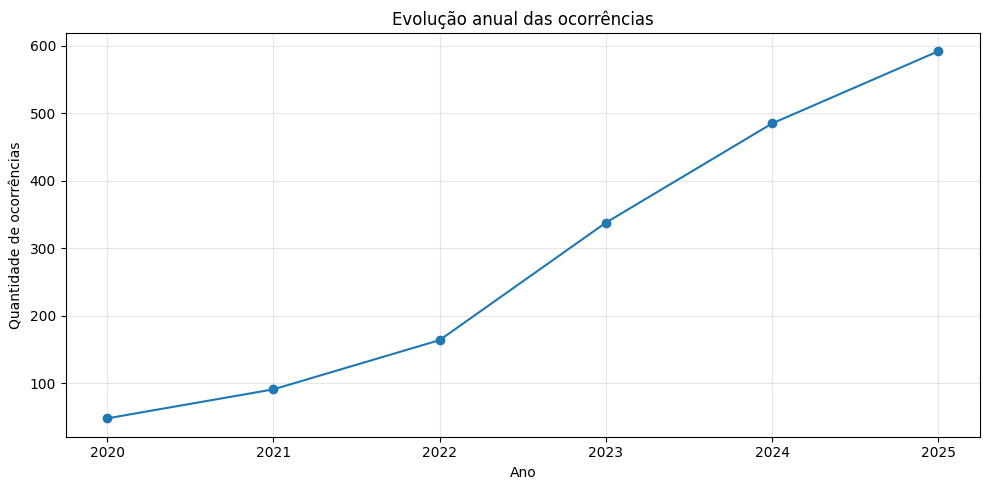

In [0]:
# ============================================================
# 6.2.1 Gráfico da evolução anual
# ============================================================

import matplotlib.pyplot as plt

pdf_anual = evolucao_anual.toPandas()

plt.figure(figsize=(10, 5))

plt.plot(
    pdf_anual["ano"],
    pdf_anual["quantidade_ocorrencias"],
    marker="o"
)

plt.title("Evolução anual das ocorrências")
plt.xlabel("Ano")
plt.ylabel("Quantidade de ocorrências")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análise 6.2.1

A análise da evolução anual mostra um crescimento contínuo do número de ocorrências registradas no período analisado. Em 2020 foram identificadas **48 ocorrências**, aumentando para **91 em 2021**, **164 em 2022**, **338 em 2023**, **485 em 2024** e atingindo **592 ocorrências em 2025**, maior valor observado na série.

Considerando os **1.718 registros** da base, o ano de 2025 concentra aproximadamente **34,5% das ocorrências**, seguido por 2024, com cerca de **28,2%**, e 2023, com aproximadamente **19,7%**. Dessa forma, os três anos mais recentes representam a maior parcela dos registros disponíveis.

Entre 2020 e 2025, a quantidade anual de registros passou de 48 para 592 ocorrências, evidenciando uma forte elevação na série. O maior crescimento percentual entre anos consecutivos ocorreu entre **2022 e 2023**, quando os registros passaram de 164 para 338 ocorrências.

Entretanto, esse crescimento deve ser interpretado como uma característica da base analisada. A elevação do número de registros não permite concluir, isoladamente, que houve aumento real da ocorrência de acidentes ao longo dos anos, pois pode também estar relacionada a fatores como ampliação da cobertura dos registros, mudanças nos processos de notificação ou maior disponibilidade de dados nos anos mais recentes.

A análise anual, portanto, evidencia uma concentração crescente de registros nos últimos anos da série e fornece uma referência importante para as análises seguintes, que irão considerar características como gravidade, agentes causadores, segmentos e localização das ocorrências.

## 6.2.2 Evolução mensal das ocorrências

In [0]:
# ============================================================
# 6.2.2 Evolução mensal das ocorrências
# ============================================================

from pyspark.sql import functions as F

evolucao_mensal = (
    df_gold_q
    .filter(
        F.col("ano").isNotNull() &
        F.col("mes").isNotNull()
    )
    .groupBy("ano", "mes")
    .agg(
        F.count("*").alias("quantidade_ocorrencias")
    )
    .withColumn(
        "ano_mes",
        F.concat(
            F.col("ano").cast("string"),
            F.lit("-"),
            F.lpad(F.col("mes").cast("string"), 2, "0")
        )
    )
    .orderBy("ano", "mes")
)

display(evolucao_mensal)

ano,mes,quantidade_ocorrencias,ano_mes
2020,1,10,2020-01
2020,10,1,2020-10
2020,11,1,2020-11
2020,12,6,2020-12
2020,2,4,2020-02
2020,3,2,2020-03
2020,5,1,2020-05
2020,6,4,2020-06
2020,7,6,2020-07
2020,8,8,2020-08


In [0]:
# ============================================================
# 6.2.2 Resumo da evolução mensal (identificação automática do
#  mês com maior e menor quantidade de ocorrências)
# ============================================================

maior_mes = (
    evolucao_mensal
    .orderBy(F.desc("quantidade_ocorrencias"))
    .first()
)

menor_mes = (
    evolucao_mensal
    .orderBy(F.asc("quantidade_ocorrencias"))
    .first()
)

print(
    f"Maior quantidade mensal: "
    f"{maior_mes['ano_mes']} - "
    f"{maior_mes['quantidade_ocorrencias']} ocorrências"
)

print(
    f"Menor quantidade mensal: "
    f"{menor_mes['ano_mes']} - "
    f"{menor_mes['quantidade_ocorrencias']} ocorrências"
)

Maior quantidade mensal: 2025-10 - 68 ocorrências
Menor quantidade mensal: 2020-11 - 1 ocorrências


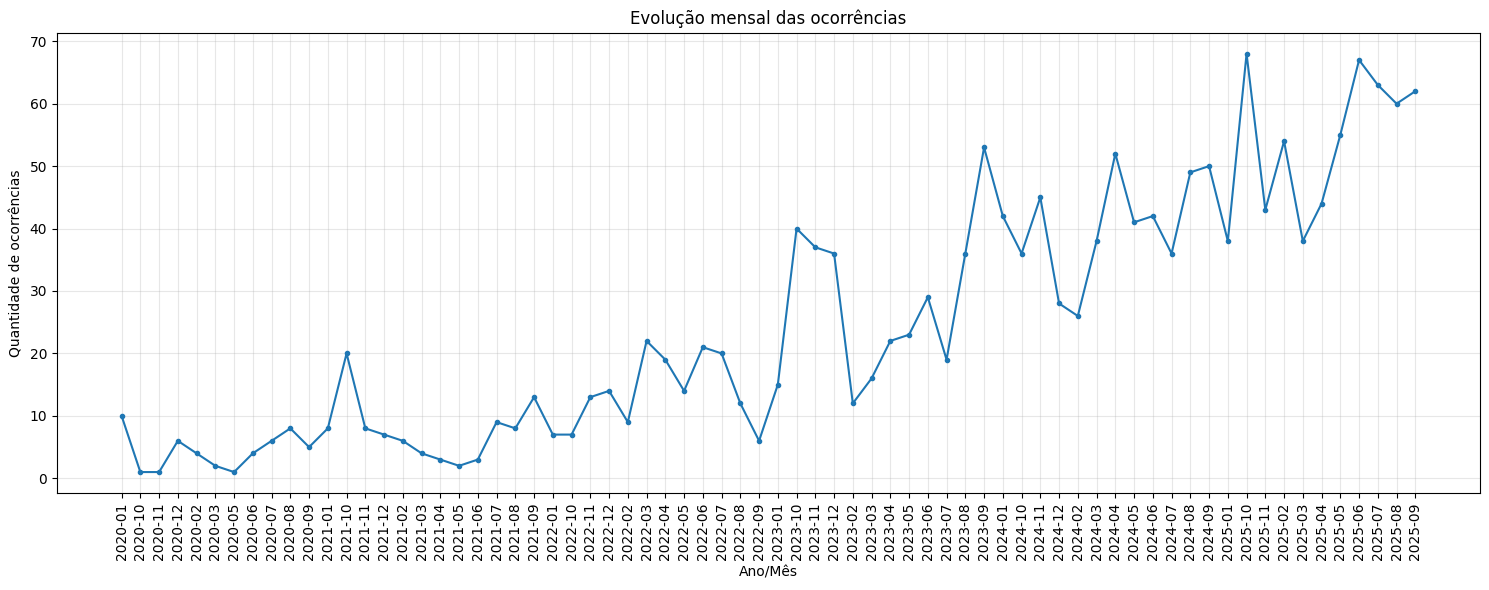

In [0]:
# ============================================================
# 6.2.2 Gráfico da evolução mensal (Gráfico)
# ============================================================

import matplotlib.pyplot as plt

pdf_mensal = evolucao_mensal.toPandas()

plt.figure(figsize=(15, 6))

plt.plot(
    pdf_mensal["ano_mes"],
    pdf_mensal["quantidade_ocorrencias"],
    marker="o",
    markersize=3
)

plt.title("Evolução mensal das ocorrências")
plt.xlabel("Ano/Mês")
plt.ylabel("Quantidade de ocorrências")

plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### Análise 6.2.2

A análise mensal das ocorrências mostra oscilações ao longo de todo o período estudado, com aumento mais evidente da quantidade de registros nos anos mais recentes.

O maior número de ocorrências em um único mês foi registrado em **outubro de 2025**, com **68 ocorrências**, enquanto o menor valor foi observado em **novembro de 2020**, com **1 ocorrência**.

O gráfico evidencia que os primeiros anos da série apresentam volumes mensais menores, enquanto a partir de 2023 passam a ocorrer valores mais elevados e maior frequência de meses com grande quantidade de registros. Esse comportamento é coerente com a tendência de crescimento identificada na análise anual.

Apesar dessa evolução, os resultados devem ser interpretados como características da base de dados analisada. As variações mensais podem refletir não apenas mudanças na ocorrência de acidentes, mas também diferenças na cobertura dos registros, no processo de notificação e na disponibilidade de dados ao longo do tempo.

Dessa forma, a análise mensal complementa a visão anual ao permitir a identificação de períodos de maior e menor concentração de registros, servindo como apoio para as análises seguintes relacionadas à gravidade, agentes causadores, segmentos e demais características das ocorrências.

### Síntese da análise do item 6.2

A análise temporal das ocorrências, considerando as perspectivas anual e mensal, evidencia aumento da quantidade de registros ao longo do período analisado, com maior concentração nos anos mais recentes.

Na análise anual, os registros passaram de **48 ocorrências em 2020** para **592 em 2025**, sendo que os anos de **2023, 2024 e 2025 concentram aproximadamente 82,4% dos 1.718 registros** da base.

A análise mensal reforça esse comportamento ao mostrar volumes mais elevados nos períodos mais recentes, apesar das oscilações entre os meses. O maior valor mensal foi observado em **outubro de 2025**, com **68 ocorrências**, enquanto o menor ocorreu em **novembro de 2020**, com **1 ocorrência**.

Em conjunto, as duas análises mostram uma concentração crescente de registros ao longo do tempo. Entretanto, esse comportamento deve ser interpretado como uma característica da base analisada, não sendo possível afirmar, apenas com esses resultados, que houve aumento real dos acidentes, uma vez que fatores relacionados à cobertura, à notificação e à disponibilidade histórica dos dados também podem influenciar a série.

Essa análise temporal fornece uma visão geral da evolução dos registros e serve de base para as próximas perguntas de negócio, que aprofundam a investigação sobre agentes causadores, gravidade, segmentos, localização e demais características das ocorrências.

## 6.3 Agentes causadores com maior número de eventos Alto/Crítico

**Pergunta de negócio:**
Quais agentes causadores apresentam maior número de eventos classificados com grau de risco Alto ou Crítico?

Para responder a esta pergunta, a análise foi dividida em três etapas complementares. 
Primeiro, é apresentada a distribuição dos eventos classificados como Alto ou Crítico por agente causador. 
Em seguida, é avaliada a participação dos principais agentes no conjunto desses eventos. 
Por fim, os resultados são interpretados de forma consolidada, destacando os agentes que mais se repetem entre as ocorrências de maior grau de risco.

- **6.3.1 Distribuição dos eventos Alto/Crítico por agente causador**;
- **6.3.2 Participação dos principais agentes causadores nos eventos Alto/Crítico**;
- **6.3.3 Análise dos resultados**.

Para facilitar a identificação de tendências, os resultados são apresentados por meio de tabelas e gráficos de linha.

## 6.3.1 Distribuição dos eventos Alto/Crítico por agente causador

Nesta etapa, foram considerados apenas os registros classificados com grau de risco Alto ou Crítico. Em seguida, os dados foram agrupados por agente causador e ordenados de forma decrescente pela quantidade de eventos.


In [0]:
# ============================================================
# 6.3.1 Distribuição dos eventos Alto/Crítico
# por agente causador
# ============================================================

from pyspark.sql import functions as F

# Carrega a tabela Gold
df_gold_q = spark.table("workspace.mvp_gold.acidentes")

# Filtra apenas eventos Alto ou Crítico
# e remove agentes causadores nulos ou inválidos
df_agentes_risco = (
    df_gold_q
    .filter(F.col("grau_de_risco").isin("Alto", "Crítico"))
    .filter(
        F.col("agente_causador").isNotNull() &
        (~F.col("agente_causador").isin("NA", "N/A", "-"))
    )
    .groupBy("agente_causador")
    .agg(
        F.count("*").alias("quantidade_eventos")
    )
)

# Seleciona os 10 maiores agentes causadores
df_top10_agentes = (
    df_agentes_risco
    .orderBy(F.col("quantidade_eventos").desc())
    .limit(10)
)

# Garante novamente a ordem do maior para o menor
df_top10_agentes = (
    df_agentes_risco
    .orderBy(F.desc("quantidade_eventos"))
    .limit(10)
)

# Exibe tabela e permite criar visualização nativa
display(df_top10_agentes)

agente_causador,quantidade_eventos
D,43
Eletricidade,40
Carro - Colisão,29
Moto - Queda,26
Golpeado por (atingido por objeto em movimento),23
Carro - Capotamento,22
Queda com diferença de nível,16
Moto - Colisão,13
Explosão,9
Atingido entre ou abaixo (esmagado ou amputado),7


Databricks visualization. Run in Databricks to view.

### Análise 6.3.1 

Os resultados mostram que o agente causador “D” apresentou o maior número de eventos classificados com grau de risco Alto ou Crítico, com 43 ocorrências, seguido de Eletricidade, com 40 ocorrências. Na sequência aparecem Carro - Colisão, com 29, e Moto - Queda, com 26 eventos.
De acordo com a nota explicativa da base de dados utilizada neste trabalho, o código “D” corresponde a agentes causadores não classificados durante o preenchimento dos registros. Portanto, embora essa categoria apresente a maior frequência entre os eventos Alto/Crítico, ela deve ser interpretada como um agrupamento de registros sem classificação específica do agente causador, e não como um agente de ocorrência propriamente dito.
Também se destacam Golpeado por (atingido por objeto em movimento), com 23 ocorrências, e Carro - Capotamento, com 22. Os demais agentes do grupo dos dez mais frequentes apresentaram valores inferiores: Queda com diferença de nível (16), Moto - Colisão (13), Explosão (9) e Atingido entre ou abaixo (esmagado ou amputado) (7).
Considerando apenas os dez agentes apresentados no gráfico, foram registrados 228 eventos Alto/Crítico. Os dois primeiros registros da ordenação, “D” e Eletricidade, concentram aproximadamente 36,4% desse conjunto. No entanto, como “D” representa registros não classificados, a interpretação analítica deve dar maior atenção aos agentes efetivamente identificados, entre os quais Eletricidade apresenta a maior frequência.
Os resultados evidenciam que alguns agentes aparecem com maior frequência nos eventos classificados nos níveis mais elevados de risco. Entretanto, a análise representa uma associação por frequência, não sendo suficiente, isoladamente, para estabelecer relação direta de causa e efeito entre o agente causador e o grau de risco.


## 6.3.2 Participação dos principais agentes causadores nos eventos Alto/Crítico

Para complementar a análise de frequência apresentada no item anterior, foi calculada a participação percentual dos agentes causadores efetivamente classificados no conjunto de eventos com grau de risco Alto ou Crítico.
Conforme a nota explicativa da base de dados utilizada neste trabalho, o código “D” representa registros cujo agente causador não foi classificado durante o preenchimento. Por esse motivo, esses registros foram mantidos na análise geral do item 6.3.1, por fazerem parte da base original, mas foram excluídos desta etapa de participação percentual, permitindo avaliar especificamente a representatividade dos agentes causadores identificados.

In [0]:
# ============================================================
# 6.3.2 Participação dos principais agentes causadores
# nos eventos Alto/Crítico
# ============================================================

from pyspark.sql import functions as F

# ------------------------------------------------------------
# Carregamento da tabela Gold
# ------------------------------------------------------------

df_gold_q = spark.table("workspace.mvp_gold.acidentes")

# ------------------------------------------------------------
# Seleciona apenas eventos Alto/Crítico e mantém
# somente agentes causadores efetivamente classificados
# ------------------------------------------------------------

df_agentes_classificados = (
    df_gold_q
    .filter(
        F.col("grau_de_risco").isin("Alto", "Crítico")
    )
    .filter(
        F.col("agente_causador").isNotNull() &
        (~F.col("agente_causador").isin("NA", "N/A", "-", "D"))
    )
)

# ------------------------------------------------------------
# Total de eventos Alto/Crítico com agente classificado
# ------------------------------------------------------------

total_eventos_classificados = df_agentes_classificados.count()

print(
    f"Total de eventos Alto/Crítico com agente causador "
    f"classificado: {total_eventos_classificados}"
)

# ------------------------------------------------------------
# Quantidade e participação percentual por agente causador
# ------------------------------------------------------------

df_participacao_agentes = (
    df_agentes_classificados
    .groupBy("agente_causador")
    .agg(
        F.count("*").alias("quantidade_eventos")
    )
    .withColumn(
        "participacao_percentual",
        F.round(
            (
                F.col("quantidade_eventos") /
                F.lit(total_eventos_classificados)
            ) * 100,
            2
        )
    )
    .orderBy(
        F.desc("quantidade_eventos"),
        F.asc("agente_causador")
    )
)

# ------------------------------------------------------------
# Seleção dos 10 agentes com maior participação
# ------------------------------------------------------------

df_top10_participacao = (
    df_participacao_agentes
    .limit(10)
)

display(df_top10_participacao)

Total de eventos Alto/Crítico com agente causador classificado: 241


agente_causador,quantidade_eventos,participacao_percentual
Eletricidade,40,16.6
Carro - Colisão,29,12.03
Moto - Queda,26,10.79
Golpeado por (atingido por objeto em movimento),23,9.54
Carro - Capotamento,22,9.13
Queda com diferença de nível,16,6.64
Moto - Colisão,13,5.39
Explosão,9,3.73
Atingido entre ou abaixo (esmagado ou amputado),7,2.9
Animal,6,2.49


Databricks visualization. Run in Databricks to view.

### Análise 6.3.2 

Após a exclusão do código “D”, que representa registros sem classificação específica do agente causador, foram identificados 241 eventos classificados como Alto ou Crítico com agente causador efetivamente identificado.
Entre esses eventos, Eletricidade apresentou a maior participação, com 40 ocorrências, correspondendo a 16,60% do total. Em seguida aparecem Carro - Colisão, com 29 eventos (12,03%), e Moto - Queda, com 26 eventos (10,79%). Esses três agentes, em conjunto, representam aproximadamente 39,42% dos eventos Alto/Crítico com agente causador classificado.
Também apresentam participação relevante Golpeado por (atingido por objeto em movimento), com 23 eventos (9,54%), e Carro - Capotamento, com 22 eventos (9,13%). Considerando os cinco principais agentes causadores, observa-se uma concentração de aproximadamente 58,09% dos eventos analisados.
Na sequência aparecem Queda com diferença de nível, com 16 ocorrências (6,64%), Moto - Colisão, com 13 (5,39%), Explosão, com 9 (3,73%), Atingido entre ou abaixo (esmagado ou amputado), com 7 (2,90%), e Animal, com 6 eventos (2,49%).
Os dez agentes apresentados no gráfico concentram aproximadamente 79,24% de todos os eventos Alto/Crítico com agente causador classificado, evidenciando que uma parcela significativa das ocorrências de maior grau de risco está concentrada em um conjunto relativamente reduzido de categorias.
O destaque de Eletricidade é particularmente relevante no contexto do setor elétrico, por apresentar a maior participação entre os agentes efetivamente classificados. Entretanto, os resultados devem ser interpretados como uma análise de frequência e representatividade, não sendo suficientes, isoladamente, para estabelecer uma relação direta de causa e efeito entre determinado agente causador e o grau de risco do evento.
Essa análise complementa o item 6.3.1 ao demonstrar não apenas a quantidade absoluta de eventos por agente causador, mas também a contribuição percentual de cada categoria no conjunto das ocorrências classificadas como Alto ou Crítico.

### Síntese da análise do item 6.3
A análise dos eventos classificados com grau de risco Alto ou Crítico mostrou que determinados agentes causadores apresentam maior recorrência e representatividade dentro do conjunto analisado.
Na distribuição inicial, o código “D” apresentou a maior frequência. Entretanto, conforme a nota explicativa da base, esse código representa registros cujo agente causador não foi classificado durante o preenchimento, não correspondendo a um agente causador específico. Por esse motivo, sua ocorrência foi mantida na análise geral do item 6.3.1, mas excluída do cálculo de participação percentual do item 6.3.2.
Entre os agentes efetivamente classificados, Eletricidade apresentou o maior número de eventos Alto/Crítico, com 40 ocorrências e participação de 16,60%, seguida por Carro - Colisão, com 29 eventos (12,03%), e Moto - Queda, com 26 eventos (10,79%).
Os cinco principais agentes causadores representam aproximadamente 58,09% dos eventos Alto/Crítico com agente identificado, enquanto os dez principais concentram cerca de 79,24%, indicando uma concentração relevante das ocorrências de maior grau de risco em um conjunto relativamente reduzido de categorias.
Os resultados permitem identificar padrões importantes para o direcionamento de ações preventivas, treinamentos, revisão de procedimentos e priorização de medidas de segurança. Entretanto, a análise demonstra frequência e associação nos registros, não permitindo estabelecer, isoladamente, uma relação direta de causa e efeito entre determinado agente causador e o grau de risco do evento.

## 6.4 Características e combinações de fatores nos eventos de maior risco e acidentes fatais

**Pergunta do Negócio:** Quais características e combinações de fatores são mais frequentes nos eventos Alto/Crítico e nos acidentes fatais, considerando segmento, estado/local e agente causador?

Esta análise busca identificar os principais padrões presentes nos eventos classificados com grau de risco Alto ou Crítico, bem como nos acidentes fatais. Para isso, são considerados atributos como segmento, estado/local e agente causador, permitindo avaliar tanto as características mais frequentes de forma individual quanto as principais combinações entre esses fatores.

A análise está organizada nos seguintes subitens:

- **6.4.1 Principais características dos eventos Alto/Crítico**
- **6.4.2 Combinações de fatores mais frequentes**
- **6.4.3 Acidentes fatais**

## 6.4.1 Principais características dos eventos Alto/Crítico

Principais características dos eventos Alto/Crítico

Neste subitem são analisadas, de forma individual, as principais características dos eventos classificados com grau de risco Alto ou Crítico, considerando as variáveis segmento, estado/local e agente causador.

O objetivo é identificar quais categorias aparecem com maior frequência nesse conjunto de eventos e qual a participação de cada uma no total analisado. Nesta etapa, as variáveis são avaliadas separadamente; as combinações entre esses fatores serão exploradas posteriormente no item 6.4.2.

Inicialmente, são selecionados apenas os registros classificados como Alto ou Crítico.

In [0]:
# ============================================================
# 6.4.1 Principais características dos eventos Alto/Crítico
# ============================================================

from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

# Seleção dos eventos classificados como Alto ou Crítico
df_alto_critico = (
    df_gold_q
    .filter(
        F.upper(F.trim(F.col("grau_de_risco")))
        .isin("ALTO", "CRÍTICO", "CRITICO")
    )
)

total_alto_critico = df_alto_critico.count()

print(f"Total de eventos Alto/Crítico: {total_alto_critico}")

Total de eventos Alto/Crítico: 345


In [0]:
# ============================================================
# Distribuição dos eventos Alto/Crítico por segmento
# ============================================================

segmento_ac = (
    df_alto_critico
    .groupBy("segmento")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_alto_critico)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(segmento_ac)

segmento,quantidade,percentual
Transmissão,153,44.35
Expansão,52,15.07
Geração - Hidráulica,45,13.04
CSC,43,12.46
Adm,26,7.54
Expansão - Proj. Estrat.,10,2.9
Geração - Térmica,8,2.32
Geração - Eólica,3,0.87
Logistica,2,0.58
Telecomunicação,2,0.58


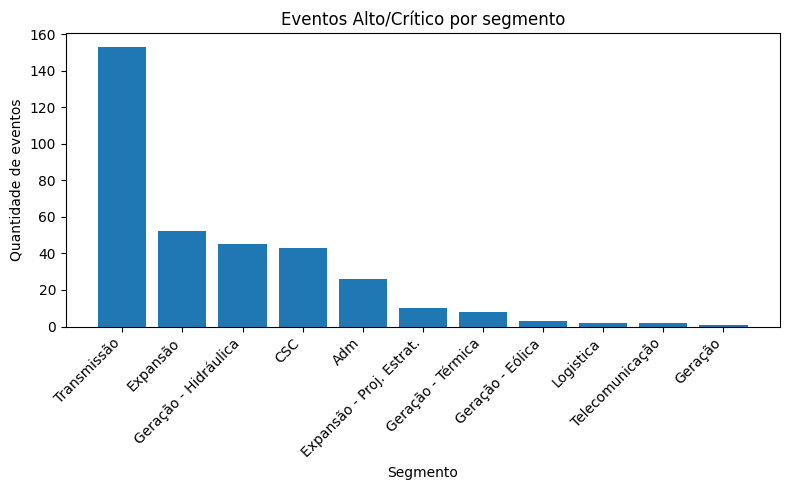

In [0]:
# Conversão para Pandas (facilitar comparação segmentos - gráfico)
segmento_pd = segmento_ac.toPandas()

# Gráfico
plt.figure(figsize=(8, 5))

plt.bar(
    segmento_pd["segmento"].astype(str),
    segmento_pd["quantidade"]
)

plt.title("Eventos Alto/Crítico por segmento")
plt.xlabel("Segmento")
plt.ylabel("Quantidade de eventos")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# Distribuição dos eventos Alto/Crítico por estado (10 estados 
# com maior número de eventos Alto/Crítico)
# ============================================================

estado_ac = (
    df_alto_critico
    .groupBy("estado")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_alto_critico)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(estado_ac)

estado,quantidade,percentual
BA,56,16.23
RS,34,9.86
PE,30,8.7
RJ,27,7.83
SP,24,6.96
SC,19,5.51
RO,18,5.22
MA,18,5.22
PA,18,5.22
MG,15,4.35


In [0]:
# ============================================================
# Distribuição dos eventos Alto/Crítico por local (10 locais 
# com maior frequência)
# ============================================================

local_ac = (
    df_alto_critico
    .groupBy("local")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_alto_critico)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(local_ac)

local,quantidade,percentual
Empresa,161,46.67
Via pública,126,36.52
Área rural,47,13.62
null,6,1.74
SPE,3,0.87
Área urbana,2,0.58


In [0]:
# ============================================================
# Distribuição dos eventos Alto/Crítico por agente causador 
# (10 agentes causadores com maior frequência entre os eventos 
# Alto/Crítico)
# ============================================================

agente_ac = (
    df_alto_critico
    .groupBy("agente_causador")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_alto_critico)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(agente_ac)

agente_causador,quantidade,percentual
null,57,16.52
D,43,12.46
Eletricidade,40,11.59
Carro - Colisão,29,8.41
Moto - Queda,26,7.54
Golpeado por (atingido por objeto em movimento),23,6.67
Carro - Capotamento,22,6.38
Queda com diferença de nível,16,4.64
Moto - Colisão,13,3.77
Explosão,9,2.61


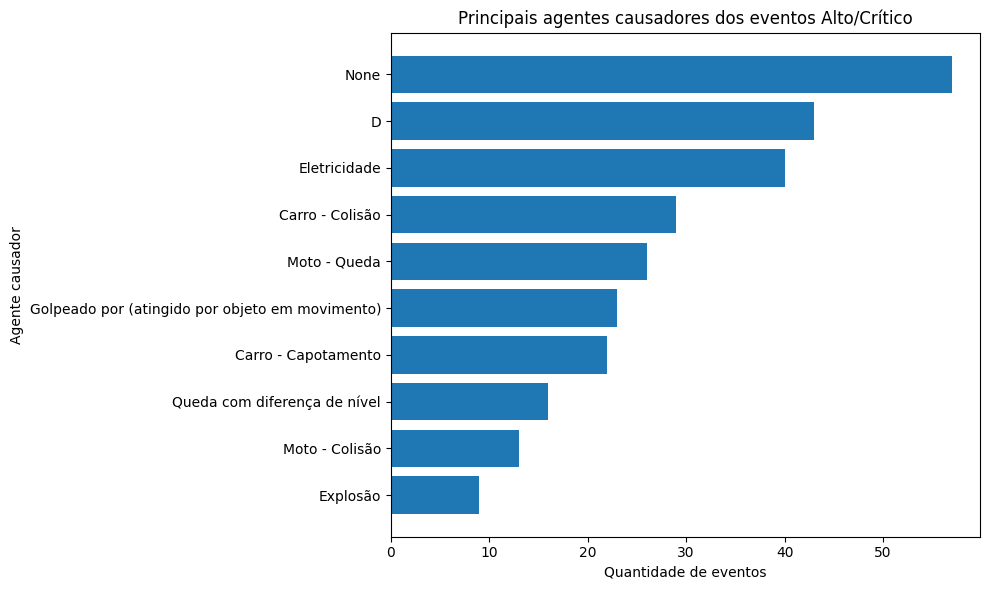

In [0]:
# Seleção dos 10 principais agentes causadores
agente_pd = agente_ac.limit(10).toPandas()

# Inverter a ordem para melhor apresentação no gráfico horizontal
agente_pd = agente_pd.iloc[::-1]

plt.figure(figsize=(10, 6))

plt.barh(
    agente_pd["agente_causador"].astype(str),
    agente_pd["quantidade"]
)

plt.title("Principais agentes causadores dos eventos Alto/Crítico")
plt.xlabel("Quantidade de eventos")
plt.ylabel("Agente causador")

plt.tight_layout()

plt.show()

### Análise 6.4.1

Foram identificados 345 eventos classificados com grau de risco Alto ou Crítico. A análise das características desses registros mostra uma concentração relevante em determinadas categorias de segmento, estado/local e agente causador.

Em relação ao segmento, a Transmissão apresenta a maior quantidade de eventos Alto/Crítico, com 153 registros (44,35%), representando quase metade dos casos analisados. Na sequência aparecem Expansão, com 52 eventos (15,07%), Geração - Hidráulica, com 45 (13,04%), e CSC, com 43 (12,46%). Esses quatro segmentos concentram a maior parcela dos eventos de maior grau de risco da base.

Na distribuição por estado, a maior quantidade de registros ocorre na Bahia (BA), com 56 eventos (16,23%), seguida por Rio Grande do Sul (RS), com 34 (9,86%), Pernambuco (PE), com 30 (8,70%), Rio de Janeiro (RJ), com 27 (7,83%), e São Paulo (SP), com 24 (6,96%). Apesar dessa concentração nos primeiros estados, os eventos Alto/Crítico encontram-se distribuídos por diferentes unidades da Federação.

Quanto ao local, observa-se forte concentração nas categorias Empresa, com 161 registros (46,67%), e Via pública, com 126 (36,52%). Juntas, essas duas categorias correspondem a aproximadamente 83% dos eventos Alto/Crítico. A categoria Área rural aparece em seguida, com 47 ocorrências (13,62%), enquanto os demais locais apresentam participação bastante reduzida.

Na análise do agente causador, inicialmente chama atenção a existência de 57 registros sem informação (null), correspondentes a 16,52% dos eventos Alto/Crítico. Também aparece a categoria “D”, com 43 registros (12,46%), cuja interpretação deve considerar a documentação e as regras de preenchimento da base. Entre os agentes causadores claramente identificados, destaca-se Eletricidade, com 40 eventos (11,59%), seguida por Carro - Colisão, com 29 (8,41%), Moto - Queda, com 26 (7,54%), Golpeado por (atingido por objeto em movimento), com 23 (6,67%), e Carro - Capotamento, com 22 (6,38%).

De forma geral, os resultados indicam que os eventos Alto/Crítico apresentam maior frequência no segmento de Transmissão, com destaque geográfico para a Bahia, e ocorrem principalmente nas categorias de local Empresa e Via pública. Entre os agentes causadores identificados, Eletricidade apresenta a maior frequência. Entretanto, a presença expressiva de registros nulos e da categoria “D” no campo agente_causador deve ser considerada como uma limitação de qualidade dos dados na interpretação dos resultados.

Essas análises apresentam as características de forma individual. No item 6.4.2 – Combinações de fatores mais frequentes, as variáveis serão avaliadas conjuntamente para verificar quais associações entre segmento, estado/local e agente causador aparecem com maior frequência nos eventos Alto/Crítico.

## 6.4.2 Combinações de fatores mais frequentes

Após a análise individual das principais características dos eventos classificados como Alto ou Crítico, este subitem avalia as combinações entre os fatores segmento, estado/local e agente causador.

O objetivo é identificar quais associações aparecem com maior frequência entre os eventos de maior grau de risco, permitindo observar padrões que não seriam percebidos pela análise isolada de cada variável.

Para manter a coerência com o item anterior, são considerados os mesmos registros classificados como Alto ou Crítico.


In [0]:
# ============================================================
# 6.4.2 Combinações de fatores mais frequentes
# ============================================================

from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt

# Reutilização da base filtrada no item 6.4.1
# df_alto_critico contém somente eventos Alto/Crítico

total_alto_critico = df_alto_critico.count()

print(f"Total de eventos Alto/Crítico analisados: {total_alto_critico}")

Total de eventos Alto/Crítico analisados: 345


segmento,estado,quantidade,percentual
Transmissão,BA,18,5.22
Transmissão,SP,15,4.35
Transmissão,RJ,14,4.06
Transmissão,PE,14,4.06
Geração - Hidráulica,BA,12,3.48
Transmissão,RO,11,3.19
Transmissão,SC,11,3.19
Transmissão,RS,11,3.19
Geração - Hidráulica,PA,9,2.61
Expansão,RS,9,2.61


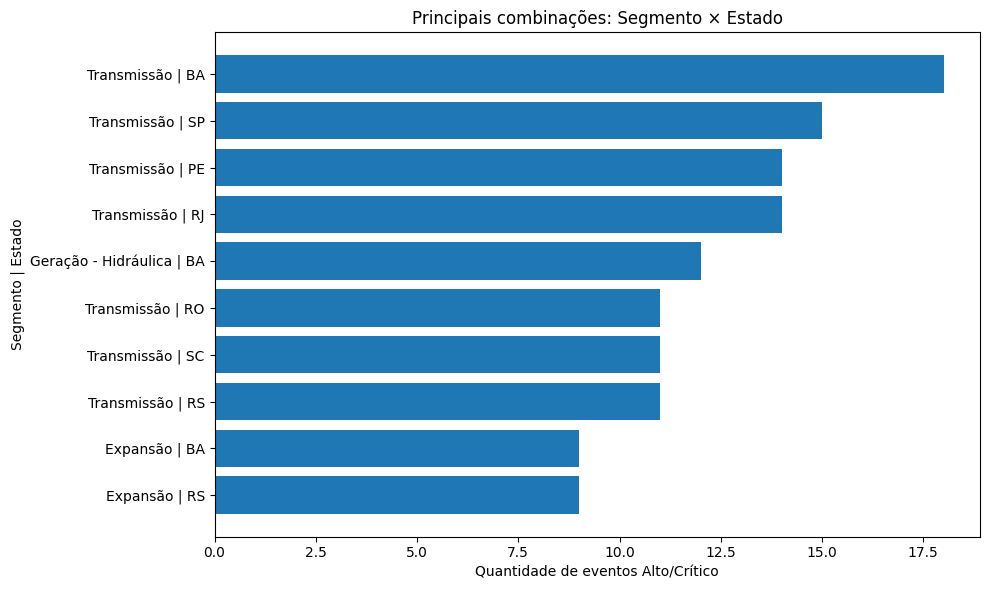

In [0]:
# ============================================================
# Combinação segmento x estado (10 combinações mais frequentes)
# ============================================================

segmento_estado_ac = (
    df_alto_critico
    .groupBy("segmento", "estado")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_alto_critico)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(segmento_estado_ac)

# Seleção das 10 principais combinações
segmento_estado_pd = (
    segmento_estado_ac
    .limit(10)
    .toPandas()
)

segmento_estado_pd["combinacao"] = (
    segmento_estado_pd["segmento"].astype(str)
    + " | "
    + segmento_estado_pd["estado"].astype(str)
)

# Inversão para gráfico horizontal
segmento_estado_pd = segmento_estado_pd.iloc[::-1]

plt.figure(figsize=(10, 6))

plt.barh(
    segmento_estado_pd["combinacao"],
    segmento_estado_pd["quantidade"]
)

plt.title("Principais combinações: Segmento × Estado")
plt.xlabel("Quantidade de eventos Alto/Crítico")
plt.ylabel("Segmento | Estado")

plt.tight_layout()
plt.show()

segmento,local,quantidade,percentual
Transmissão,Empresa,59,17.1
Transmissão,Via pública,54,15.65
Transmissão,Área rural,37,10.72
Expansão,Empresa,28,8.12
Geração - Hidráulica,Empresa,26,7.54
CSC,Via pública,21,6.09
CSC,Empresa,19,5.51
Expansão,Via pública,16,4.64
Geração - Hidráulica,Via pública,16,4.64
Adm,Via pública,14,4.06


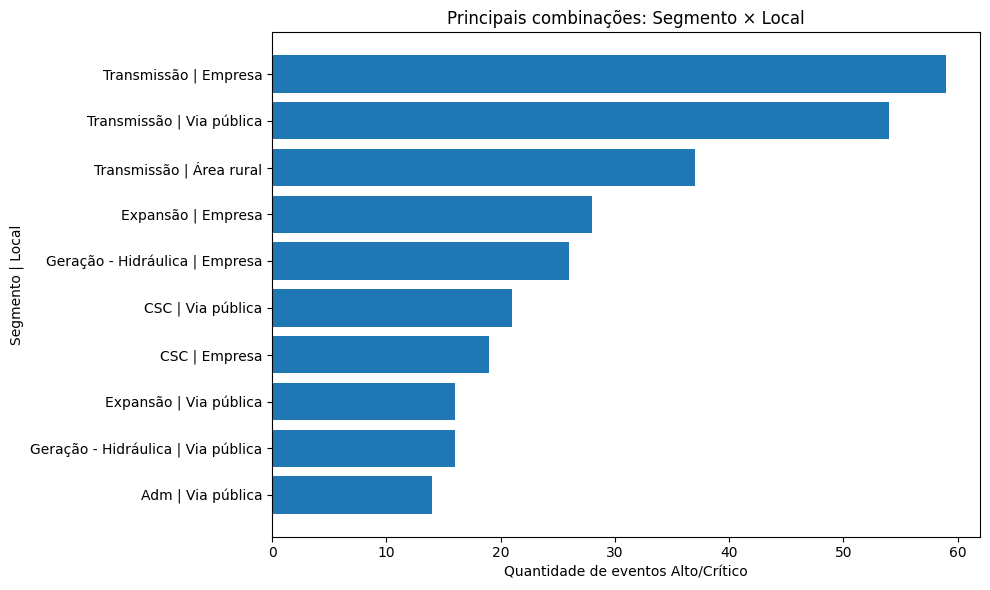

In [0]:
# ============================================================
# Combinação segmento x local
# ============================================================

segmento_local_ac = (
    df_alto_critico
    .groupBy("segmento", "local")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_alto_critico)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(segmento_local_ac)

# Seleção das 10 principais combinações
segmento_local_pd = (
    segmento_local_ac
    .limit(10)
    .toPandas()
)

segmento_local_pd["combinacao"] = (
    segmento_local_pd["segmento"].astype(str)
    + " | "
    + segmento_local_pd["local"].astype(str)
)

segmento_local_pd = segmento_local_pd.iloc[::-1]

plt.figure(figsize=(10, 6))

plt.barh(
    segmento_local_pd["combinacao"],
    segmento_local_pd["quantidade"]
)

plt.title("Principais combinações: Segmento × Local")
plt.xlabel("Quantidade de eventos Alto/Crítico")
plt.ylabel("Segmento | Local")

plt.tight_layout()
plt.show()

segmento,agente_causador,quantidade,percentual
Transmissão,null,32,9.28
Transmissão,Eletricidade,27,7.83
Transmissão,Carro - Capotamento,19,5.51
CSC,null,14,4.06
Transmissão,D,13,3.77
Transmissão,Golpeado por (atingido por objeto em movimento),12,3.48
Expansão,D,11,3.19
Geração - Hidráulica,D,9,2.61
Transmissão,Moto - Queda,8,2.32
Expansão,Carro - Colisão,8,2.32


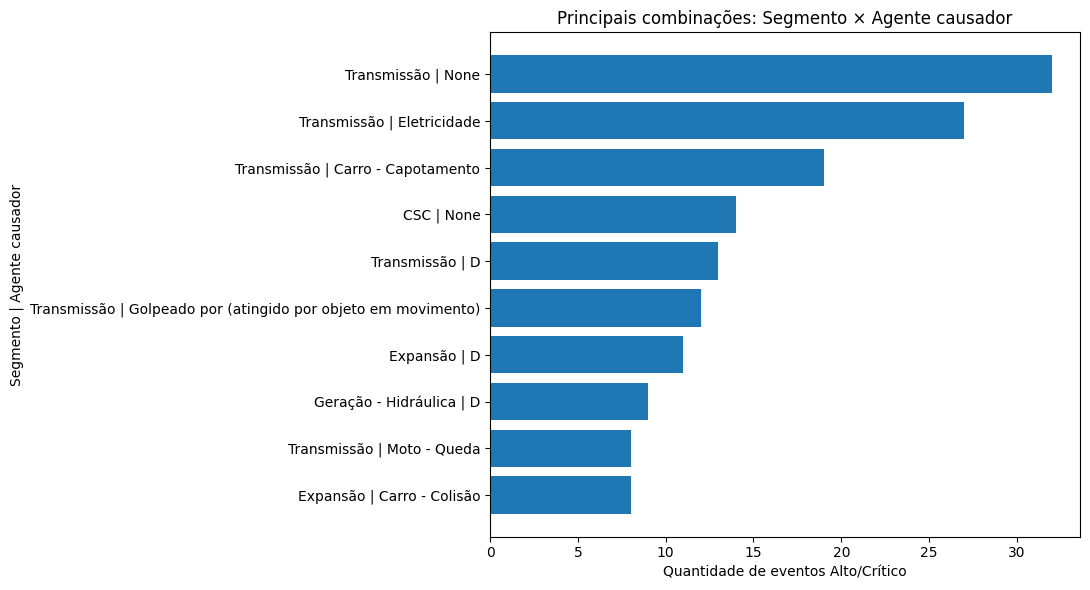

In [0]:
# ============================================================
# Combinação segmento x agente causador
# ============================================================

segmento_agente_ac = (
    df_alto_critico
    .groupBy("segmento", "agente_causador")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_alto_critico)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(segmento_agente_ac)

# Seleção das 10 principais combinações
segmento_agente_pd = (
    segmento_agente_ac
    .limit(10)
    .toPandas()
)

segmento_agente_pd["combinacao"] = (
    segmento_agente_pd["segmento"].astype(str)
    + " | "
    + segmento_agente_pd["agente_causador"].astype(str)
)

segmento_agente_pd = segmento_agente_pd.iloc[::-1]

plt.figure(figsize=(11, 6))

plt.barh(
    segmento_agente_pd["combinacao"],
    segmento_agente_pd["quantidade"]
)

plt.title("Principais combinações: Segmento × Agente causador")
plt.xlabel("Quantidade de eventos Alto/Crítico")
plt.ylabel("Segmento | Agente causador")

plt.tight_layout()
plt.show()

estado,agente_causador,quantidade,percentual
BA,D,16,4.64
MA,null,7,2.03
BA,Carro - Colisão,7,2.03
PE,Carro - Capotamento,7,2.03
SP,null,7,2.03
RJ,Carro - Capotamento,6,1.74
PE,Carro - Colisão,6,1.74
BA,Eletricidade,6,1.74
PE,Eletricidade,6,1.74
MG,null,6,1.74


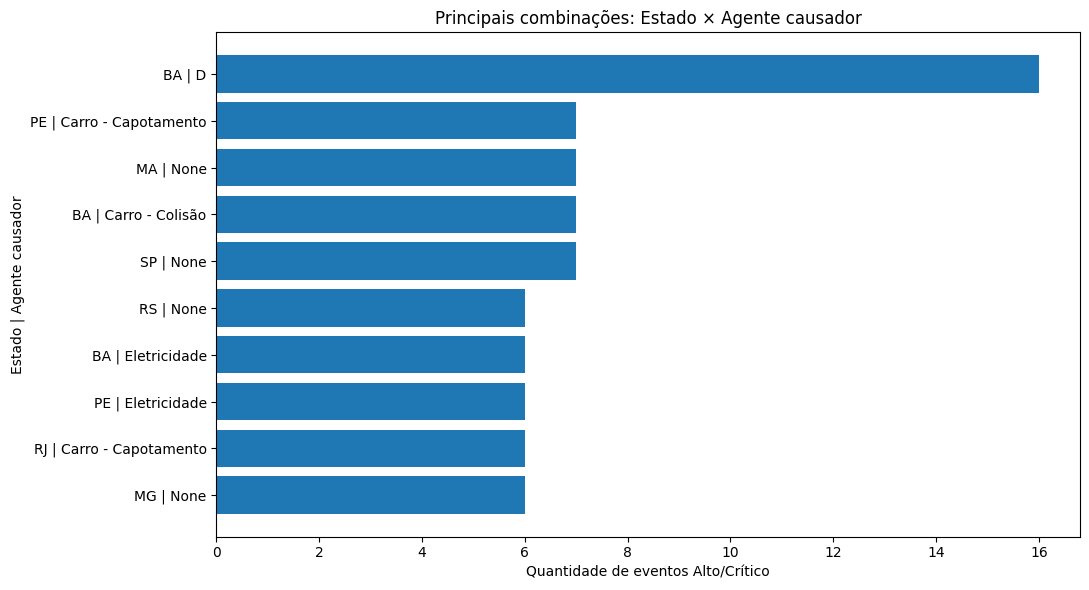

In [0]:
# ============================================================
# Combinação estado x agente causador
# ============================================================

estado_agente_ac = (
    df_alto_critico
    .groupBy("estado", "agente_causador")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_alto_critico)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(estado_agente_ac)

# Seleção das 10 principais combinações
estado_agente_pd = (
    estado_agente_ac
    .limit(10)
    .toPandas()
)

estado_agente_pd["combinacao"] = (
    estado_agente_pd["estado"].astype(str)
    + " | "
    + estado_agente_pd["agente_causador"].astype(str)
)

estado_agente_pd = estado_agente_pd.iloc[::-1]

plt.figure(figsize=(11, 6))

plt.barh(
    estado_agente_pd["combinacao"],
    estado_agente_pd["quantidade"]
)

plt.title("Principais combinações: Estado × Agente causador")
plt.xlabel("Quantidade de eventos Alto/Crítico")
plt.ylabel("Estado | Agente causador")

plt.tight_layout()
plt.show()

### Análise 6.4.2

A análise conjunta das características dos 345 eventos classificados como Alto ou Crítico permite identificar combinações recorrentes entre segmento, estado, local e agente causador, complementando a análise individual realizada no item 6.4.1.

No cruzamento entre segmento e estado, observa-se predominância do segmento Transmissão entre as combinações mais frequentes. A combinação Transmissão | BA apresenta o maior número de registros, com 18 eventos, seguida por Transmissão | SP, com 15, e pelas combinações Transmissão | PE e Transmissão | RJ, ambas com 14 eventos. Também se destaca Geração - Hidráulica | BA, com 12 registros. Esse resultado reforça a participação expressiva da Transmissão já identificada na análise individual, mas mostra como esses registros se distribuem entre diferentes estados.

No cruzamento entre segmento e local, as maiores concentrações também estão relacionadas à Transmissão. Destacam-se Transmissão | Empresa, com 59 eventos, e Transmissão | Via pública, com 54 registros, seguidas por Transmissão | Área rural, com 35 ocorrências. Também aparecem entre as principais combinações Expansão | Empresa, Geração - Hidráulica | Empresa e as combinações do CSC com Via pública e Empresa. Esses resultados mostram que a concentração observada anteriormente nas categorias Empresa e Via pública está fortemente associada ao segmento de Transmissão.

Na combinação entre segmento e agente causador, novamente o segmento Transmissão aparece de forma predominante. Entre as associações mais frequentes estão registros de Transmissão vinculados a Eletricidade, Carro - Capotamento, Golpeado por (atingido por objeto em movimento) e Moto - Queda. Entretanto, também aparecem entre as primeiras posições registros com agente causador não informado (None) e com a categoria “D”, o que evidencia a influência de problemas de preenchimento do campo agente_causador sobre os resultados desse cruzamento.

O cruzamento entre estado e agente causador apresenta maior dispersão. A combinação BA | D é a mais frequente, com 16 eventos. Outras combinações aparecem com quantidades menores, envolvendo diferentes estados e agentes, como Carro - Capotamento, Carro - Colisão e Eletricidade. Também são observados registros com agente causador não informado, reforçando a necessidade de cautela na interpretação dessa variável.

De forma geral, os cruzamentos mostram que a maior concentração de eventos Alto/Crítico está associada ao segmento de Transmissão, especialmente quando combinado com determinados estados e com os locais Empresa e Via pública. Para os agentes causadores, Eletricidade e diferentes tipos de acidentes veiculares aparecem em combinações relevantes, embora a presença de valores null e da categoria “D” limite uma interpretação mais precisa de algumas associações.

Os resultados representam frequências observadas na base de dados e não devem ser interpretados isoladamente como indicação de maior probabilidade de ocorrência ou maior risco relativo, uma vez que não foram considerados dados de exposição, como número de trabalhadores, quantidade de instalações ou volume de atividades de cada segmento ou estado.

No próximo subitem, 6.4.3 – Acidentes fatais, a análise será direcionada especificamente aos registros de fatalidade, buscando identificar suas principais características e verificar se os padrões observados nesse grupo apresentam diferenças em relação ao conjunto dos eventos Alto/Crítico.

## 6.4.3 Acidentes fatais
Neste subitem são analisados especificamente os registros classificados como Fatalidade ou Fatalidade Trajeto na coluna classificacao.
O objetivo é identificar as principais características dos acidentes fatais presentes na base, considerando segmento, estado, local e agente causador, de forma a complementar as análises anteriores sobre eventos Alto/Crítico.
Para esta análise, as duas classificações são consolidadas em um único conjunto denominado acidentes fatais.

In [0]:
# ============================================================
# 6.4.3 Acidentes fatais
# ============================================================

from pyspark.sql import functions as F

df_fatais = (
    df_gold_q
    .filter(
        F.upper(F.trim(F.col("classificacao"))).isin(
            "FATALIDADE",
            "FATALIDADE TRAJETO"
        )
    )
)

total_fatais = df_fatais.count()

print(f"Total de acidentes fatais: {total_fatais}")

Total de acidentes fatais: 15


In [0]:
# ============================================================
# Distribuição por tipo de fatalidade
# ============================================================

fatal_classificacao = (
    df_fatais
    .groupBy("classificacao")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_fatais)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(fatal_classificacao)

classificacao,quantidade,percentual
Fatalidade,9,60.0
Fatalidade Trajeto,6,40.0


In [0]:
# ============================================================
# Acidentes fatais por segmento 
# ============================================================

fatal_segmento = (
    df_fatais
    .groupBy("segmento")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_fatais)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(fatal_segmento)

segmento,quantidade,percentual
Transmissão,8,53.33
CSC,5,33.33
Expansão,1,6.67
Adm,1,6.67


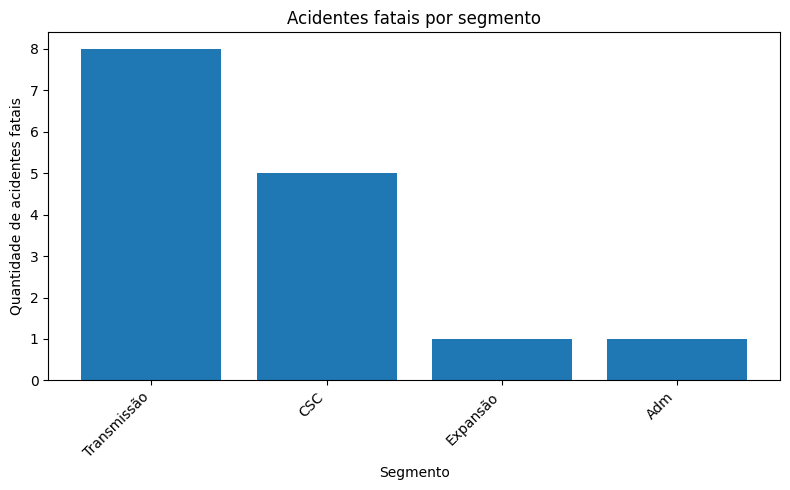

In [0]:
fatal_segmento_pd = fatal_segmento.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    fatal_segmento_pd["segmento"].astype(str),
    fatal_segmento_pd["quantidade"]
)

plt.title("Acidentes fatais por segmento")
plt.xlabel("Segmento")
plt.ylabel("Quantidade de acidentes fatais")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# Acidentes fatais por estado
# ============================================================

fatal_estado = (
    df_fatais
    .groupBy("estado")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_fatais)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(fatal_estado)

estado,quantidade,percentual
RN,3,20.0
PE,3,20.0
PB,2,13.33
GO,2,13.33
PA,2,13.33
PR,1,6.67
BA,1,6.67
SE,1,6.67


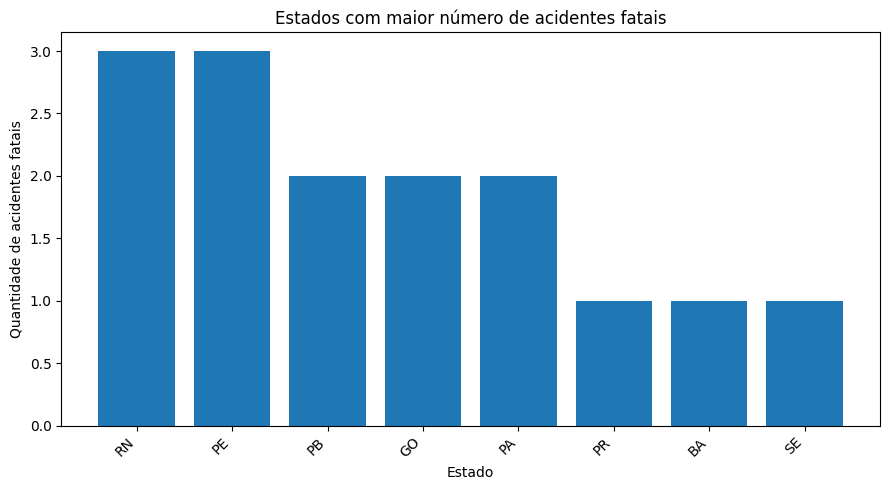

In [0]:
fatal_estado_pd = fatal_estado.limit(10).toPandas()

plt.figure(figsize=(9, 5))

plt.bar(
    fatal_estado_pd["estado"].astype(str),
    fatal_estado_pd["quantidade"]
)

plt.title("Estados com maior número de acidentes fatais")
plt.xlabel("Estado")
plt.ylabel("Quantidade de acidentes fatais")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# Acidentes fatais por local
# ============================================================

fatal_local = (
    df_fatais
    .groupBy("local")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_fatais)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(fatal_local)

local,quantidade,percentual
Via pública,9,60.0
Empresa,4,26.67
Área rural,2,13.33


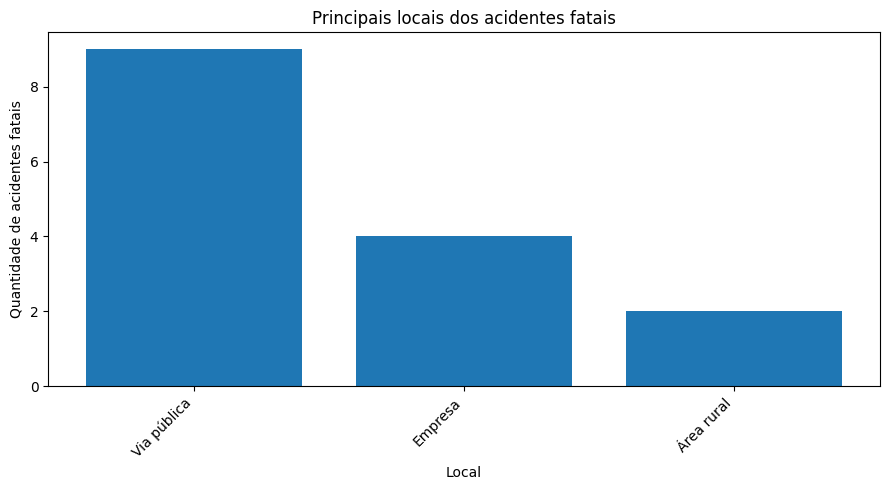

In [0]:
fatal_local_pd = fatal_local.limit(10).toPandas()

plt.figure(figsize=(9, 5))

plt.bar(
    fatal_local_pd["local"].astype(str),
    fatal_local_pd["quantidade"]
)

plt.title("Principais locais dos acidentes fatais")
plt.xlabel("Local")
plt.ylabel("Quantidade de acidentes fatais")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [0]:
# ============================================================
# Tratamento do agente causador
# ============================================================

df_fatais_tratado = (
    df_fatais
    .withColumn(
        "agente_tratado",
        F.when(
            F.col("agente_causador").isNull()
            | (F.trim(F.col("agente_causador")) == ""),
            "Não informado"
        )
        .when(
            F.upper(F.trim(F.col("agente_causador"))) == "D",
            "D - categoria não detalhada"
        )
        .otherwise(F.trim(F.col("agente_causador")))
    )
)

In [0]:
# ============================================================
# Acidentes fatais por agente causador
# ============================================================

fatal_agente = (
    df_fatais_tratado
    .groupBy("agente_tratado")
    .count()
    .withColumnRenamed("count", "quantidade")
    .withColumn(
        "percentual",
        F.round(
            (F.col("quantidade") / F.lit(total_fatais)) * 100,
            2
        )
    )
    .orderBy(F.desc("quantidade"))
)

display(fatal_agente)

agente_tratado,quantidade,percentual
Queda com diferença de nível,4,26.67
D - categoria não detalhada,4,26.67
Eletricidade,2,13.33
Não informado,2,13.33
Carro - Colisão,1,6.67
Moto - Queda,1,6.67
Carro - Capotamento,1,6.67


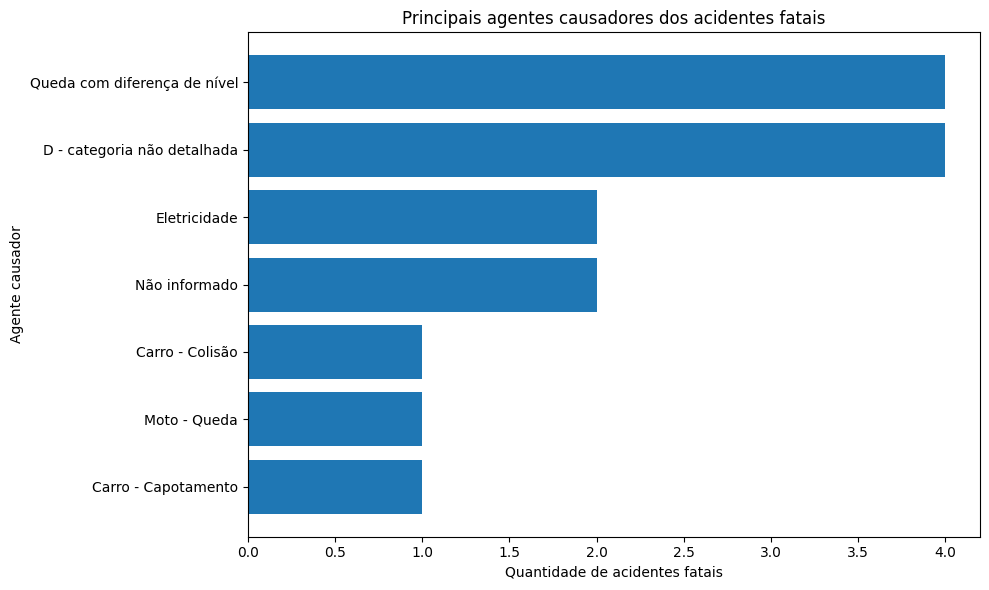

In [0]:
fatal_agente_pd = fatal_agente.limit(10).toPandas()

fatal_agente_pd = fatal_agente_pd.iloc[::-1]

plt.figure(figsize=(10, 6))

plt.barh(
    fatal_agente_pd["agente_tratado"],
    fatal_agente_pd["quantidade"]
)

plt.title("Principais agentes causadores dos acidentes fatais")
plt.xlabel("Quantidade de acidentes fatais")
plt.ylabel("Agente causador")

plt.tight_layout()

plt.show()

### Análise 6.4.3

Foram identificados 18 acidentes fatais, distribuídos igualmente entre as classificações Fatalidade e Fatalidade Trajeto, com 9 registros em cada categoria.

Em relação ao segmento, observa-se predominância da Transmissão, com 9 registros, seguida pelo CSC, com 5 ocorrências. A distribuição por estado é mais dispersa, sem uma concentração tão acentuada quanto a observada entre os segmentos.

Quanto ao local, destaca-se Via pública, com 9 registros, seguida por Empresa, com 4, indicando participação relevante dos acidentes relacionados a ambientes externos e deslocamentos.

Entre os agentes causadores, aparecem com maior frequência Queda com diferença de nível e a categoria “D”, com 4 registros cada. Também se destacam Eletricidade e os registros não informados, com 2 ocorrências cada, além de eventos relacionados a veículos.

De forma geral, os acidentes fatais apresentam maior concentração no segmento de Transmissão e em vias públicas, enquanto os agentes causadores mostram maior diversidade. A presença da categoria “D” e de valores não informados deve ser considerada como uma limitação da qualidade dos dados na interpretação desses resultados.

Esses resultados complementam as análises dos itens 6.4.1 e 6.4.2, permitindo caracterizar especificamente os eventos de maior consequência registrados na base.

### 6.5 Síntese das respostas às perguntas de negócio

A análise das características e combinações de fatores dos eventos de maior risco mostrou que os 345 eventos classificados como Alto ou Crítico apresentam maior concentração no segmento de Transmissão, especialmente em determinados estados e nos locais Empresa e Via pública.

Quando as variáveis foram analisadas em conjunto, a Transmissão permaneceu entre as combinações mais frequentes, principalmente nas associações com estado, local e agente causador. Entre os agentes identificados, destacam-se Eletricidade, ocorrências relacionadas a veículos e outros fatores operacionais, embora a presença de valores não informados e da categoria “D” limite parte da interpretação.

Na análise específica dos 18 acidentes fatais, houve distribuição igual entre Fatalidade e Fatalidade Trajeto, com destaque novamente para o segmento de Transmissão e para ocorrências em Via pública. Entre os agentes causadores dos casos fatais, apareceram com maior frequência Queda com diferença de nível e a categoria “D”.

De forma geral, o item 6.4 evidencia padrões recorrentes relacionados a segmento, localização e agente causador, permitindo caracterizar melhor os eventos de maior severidade presentes na base. Os resultados representam frequências observadas e devem ser interpretados considerando as limitações de qualidade dos dados e a ausência de medidas de exposição que permitam comparar risco relativo entre segmentos ou localidades.

## 7. Autoavaliação

O desenvolvimento deste MVP permitiu atingir o objetivo proposto de organizar e analisar registros de segurança do setor elétrico, com foco na identificação de padrões relacionados às ocorrências de maior risco e aos acidentes fatais.

A utilização do Databricks e da arquitetura medalhão contribuiu para estruturar o processamento dos dados em etapas bem definidas, desde a carga na camada Bronze, passando pelo tratamento e padronização na Silver, até a disponibilização da base analítica na Gold. Ao longo desse processo, também foi possível avaliar a qualidade dos dados e identificar valores nulos, diferenças de preenchimento e inconsistências em campos categóricos, aspectos considerados durante a interpretação dos resultados.

As análises realizadas permitiram responder às perguntas de negócio definidas no início do trabalho, incluindo a distribuição das ocorrências por grau de risco, a evolução temporal, os principais agentes causadores e as características dos eventos Alto/Crítico e dos acidentes fatais.

Para este MVP, foi adotado um modelo de dados em tabela flat na camada Gold, principalmente pela simplicidade de implementação e pelo tempo disponível para o desenvolvimento. O modelo mostrou-se adequado para responder às análises propostas. Como evolução, o projeto poderá adotar um modelo dimensional em esquema estrela, com uma tabela fato de ocorrências e dimensões como tempo, localidade, segmento, agente causador e classificação do acidente.

Essa evolução poderá melhorar a organização e reutilização dos dados, facilitar novos cruzamentos e permitir análises mais consistentes. Outros próximos passos incluem aprimorar a padronização dos dados, tratar de forma mais completa os registros incompletos, ampliar a série histórica e desenvolver indicadores e dashboards para acompanhamento dos eventos de maior risco.

De forma geral, o MVP demonstrou a viabilidade de estruturar os dados de segurança em um pipeline analítico e utilizá-los como apoio à identificação de padrões relevantes para a gestão da segurança.